# Solute Transport Toy: mPCN P vs rho sweep

Run mPCN across P and rho for the advection-diffusion toy, with pCN and MESS baselines and cached diagnostics in a proposal plane.

## Notebook summary (auto)
- Builds a shared-draws advection-diffusion toy problem with fixed dimension.
- Sweeps mPCN over P and rho, plus pCN and MESS baselines.
- Caches chains, metrics, and mPCN diagnostics for reloads.
- Produces diagnostics/plots: proposal-plane ellipses, traceplots, histograms, ESS/MSJD curves, rejection rates, and edge-rho zooms.
- Exports figures to reports/solute_transport and tables for ESS/MSJD.

In [1]:
import os
from pathlib import Path
import time
import json
import hashlib

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def _resolve_repo_root():
    env_root = os.environ.get("MULTIPROPOSAL_RUN_ROOT")
    if env_root:
        return Path(env_root).expanduser().resolve()
    root = Path.cwd().resolve()
    while root != root.parent and not (root / "pyproject.toml").exists():
        root = root.parent
    return root

repo_root = _resolve_repo_root()

from multiproposal.problems.advection_diffusion import (
    make_omegas_power,
    make_Astar_nn,
    make_Astar_from_atrue,
    params_from_skew,
    prior_diag_from_powerlaw,
    solve_theta,
)
from multiproposal.problems.advection_diffusion import AdvectionDiffusionToy
from multiproposal.algorithms.mpcn import mpcn_chain
from multiproposal.algorithms.pcn import pcn_chain
from multiproposal.algorithms.mess import mess_step
from multiproposal.algorithms.effective_sample_size import (
    estimate_effective_sample_size,
    summarize_squared_jumping_distance,
)
from multiproposal.utils.run_paths import format_float_tag
from multiproposal.plotting.figure_style import apply_pub_style

import importlib
import multiproposal.plotting.sweep_plots
importlib.reload(multiproposal.plotting.sweep_plots)
from multiproposal.plotting.sweep_plots import (
    plot_trace_grid,
    plot_ess_msjd_vs_rho,
    plot_ess_msjd_per_param_vs_rho,
    plot_rejection_vs_rho,
)

In [2]:
# Data configuration (from solute transport toy notebook)
seed_data = 0
seed_mcmc = 0

d = 10
kappa = 0.02
sigma = 0.5
alpha = 3.0
gamma = 2.0
tau2 = 2.0
a_mode = 'nearest_neighbor'
use_prior_A = True
shared_draws_seed = seed_data

obs_highest_freq = 6
obs_bandwidth = 3
obs_config = 'central_modes'

print('d:', d)
print('kappa:', kappa)
print('sigma:', sigma)
print('obs_config:', obs_config)

d: 10
kappa: 0.02
sigma: 0.5
obs_config: central_modes


In [3]:
if isinstance(obs_config, dict):
    obs_config_serializable = {
        key: (val.tolist() if isinstance(val, np.ndarray) else val)
        for key, val in obs_config.items()
    }
else:
    obs_config_serializable = obs_config
data_id_config = {
    'seed_data': seed_data,
    'seed_mcmc': seed_mcmc,
    'kappa': kappa,
    'sigma': sigma,
    'alpha': alpha,
    'gamma': gamma,
    'tau2': tau2,
    'a_mode': a_mode,
    'use_prior_A': use_prior_A,
    'shared_draws_seed': shared_draws_seed,
    'obs_highest_freq': obs_highest_freq,
    'obs_bandwidth': obs_bandwidth,
    'obs_config': obs_config_serializable,
}
data_config = dict(data_id_config)
data_config.update({
    'd': d,
})

In [4]:
# Sweep configuration (used for file naming)
n_iters = 300000
P_list = [10, 20, 30, 40, 100, 300, 500, 1000]
# P_list = [10, 20, 30, 40, 100] # for quick testing --- IGNORE ---
M_list = P_list
rho_list = [round(val, 3) for val in np.arange(0, 1.01, 0.05)]
seed_base = 202
run_pcn = True
run_mess = False
run_independent_pcn = True
independent_pcn_count = 100

# Parallel execution (mPCN)
use_parallel_mpcn = False
if use_parallel_mpcn:
    mpcn_parallel_n_jobs = 12
    mpcn_parallel_backend = "process"
    mpcn_parallelize_props = False
    mpcn_llh_chunk_size = 0
else:
    # Force serial likelihood evaluation
    mpcn_parallel_n_jobs = 1
    mpcn_parallel_backend = "auto"
    mpcn_parallelize_props = False
    mpcn_llh_chunk_size = 0

# rest of configuration (not for file naming)
max_lag = 5000 # this is for metrics, not an algo param, dont consider for file names
plot_iter = 0
n_diag_samples = 100
burn_in = 5000 # also not tobe included in the file naming
algo_config = {
    'n_iters': n_iters,
    'burn_in': burn_in,
    'max_lag': max_lag,
    'n_diag_samples': n_diag_samples,
}
execution_config = {
    'mpcn_parallel_n_jobs': mpcn_parallel_n_jobs,
    'mpcn_parallel_backend': mpcn_parallel_backend,
    'mpcn_parallelize_props': mpcn_parallelize_props,
    'mpcn_llh_chunk_size': mpcn_llh_chunk_size,
}
sweep_config = {
    'P_list': P_list,
    'M_list': M_list,
    'rho_list': rho_list,
    'seed_base': seed_base,
    'run_pcn': run_pcn,
    'run_mess': run_mess,
}

# Optional overrides to reuse an existing run directory exactly.
data_id_override = "data_h5d92590a6971"
run_id_override = "mpcn_rho_sweep_h0546a8b4ce54"

def _canonicalize_payload(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.floating, np.integer)):
        return obj.item()
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, dict):
        return {key: _canonicalize_payload(val) for key, val in sorted(obj.items())}
    if isinstance(obj, (list, tuple)):
        return [_canonicalize_payload(val) for val in obj]
    return obj

def _stable_hash(payload, length=12):
    data = json.dumps(
        _canonicalize_payload(payload),
        sort_keys=True,
        separators=(",", ":"),
        ensure_ascii=True,
    ).encode("utf-8")
    return hashlib.sha256(data).hexdigest()[:length]

In [5]:
data_id = data_id_override or f"data_h{_stable_hash(data_id_config)}"
run_id = run_id_override or f"mpcn_rho_sweep_h{_stable_hash({
    'algorithm': 'mpcn_rho_sweep',
    'algorithm_config': algo_config,
    'sweep': sweep_config,
})}"
estimations_dir = repo_root / "estimations" / "solute_transport" / data_id / "sweep" / run_id
reports_dir = repo_root / "reports" / "solute_transport" / data_id / "sweep" / run_id
for path in (estimations_dir, reports_dir):
    path.mkdir(parents=True, exist_ok=True)
run_config = {
    'dataset': 'solute_transport',
    'algorithm': 'mpcn_rho_sweep',
    'data': data_config,
    'algorithm_config': algo_config,
    'execution': execution_config,
    'sweep': sweep_config,
}
config_path = estimations_dir / "config.json"
if not config_path.exists():
    payload = dict(run_config)
    payload['data_id'] = data_id
    payload['run_id'] = run_id
    with open(config_path, 'w', encoding='utf-8') as handle:
        json.dump(payload, handle, indent=2)

print('P_list:', P_list)
print('rho_list:', rho_list)
print('n_iters:', n_iters)
print('n_diag_samples:', n_diag_samples)
print('run_pcn:', run_pcn)
print('run_mess:', run_mess)
print('use_parallel_mpcn:', use_parallel_mpcn)
print('mpcn_parallel_backend:', mpcn_parallel_backend)
print('mpcn_parallel_n_jobs:', mpcn_parallel_n_jobs)
print('mpcn_parallelize_props:', mpcn_parallelize_props)
print('mpcn_llh_chunk_size:', mpcn_llh_chunk_size)
print('data_id:', data_id)
print('run_id:', run_id)
print('Run directory:', estimations_dir)

P_list: [10, 20, 30, 40, 100, 300, 500, 1000]
rho_list: [np.float64(0.0), np.float64(0.05), np.float64(0.1), np.float64(0.15), np.float64(0.2), np.float64(0.25), np.float64(0.3), np.float64(0.35), np.float64(0.4), np.float64(0.45), np.float64(0.5), np.float64(0.55), np.float64(0.6), np.float64(0.65), np.float64(0.7), np.float64(0.75), np.float64(0.8), np.float64(0.85), np.float64(0.9), np.float64(0.95), np.float64(1.0)]
n_iters: 300000
n_diag_samples: 100
run_pcn: True
run_mess: False
use_parallel_mpcn: False
mpcn_parallel_backend: auto
mpcn_parallel_n_jobs: 1
mpcn_parallelize_props: False
mpcn_llh_chunk_size: 0
data_id: data_h5d92590a6971
run_id: mpcn_rho_sweep_h0546a8b4ce54
Run directory: /home/senng/multiproposal-internal/estimations/solute_transport/data_h5d92590a6971/sweep/mpcn_rho_sweep_h0546a8b4ce54


In [6]:
def compute_msjd_per_param(chain):
    if chain.shape[0] < 2:
        return np.zeros(chain.shape[1])
    jumps = np.diff(chain, axis=0)
    msjd = np.mean(jumps * jumps, axis=0)
    return msjd


def compute_ess_per_param(chain, max_lag):
    if chain.shape[0] < 2:
        return np.zeros(chain.shape[1])
    variances = np.var(chain, axis=0)
    if np.all(variances == 0):
        return np.zeros(chain.shape[1])
    ess_vals = estimate_effective_sample_size(chain, max_lag=max_lag)
    ess_vals = np.asarray(ess_vals, dtype=float)
    ess_vals[variances == 0] = 0.0
    return ess_vals


def summarize_chain_metrics(chain, runtime_sec, burn_in, max_lag, include_msjd_distribution=False, parallel_info=None):
    post = chain[burn_in:]
    ess_vals = compute_ess_per_param(post, max_lag=max_lag)
    msjd_vals = compute_msjd_per_param(post)
    msjd_summary = summarize_squared_jumping_distance(
        post,
        percentiles=(0.5, 2.5, 50.0, 97.5, 99.5),
        return_distribution=include_msjd_distribution,
    )
    ess_mean = float(np.nanmean(ess_vals)) if ess_vals.size else 0.0
    msjd_mean = float(np.nanmean(msjd_vals)) if msjd_vals.size else 0.0
    runtime_min = runtime_sec / 60.0
    ess_per_min = ess_mean / runtime_min if runtime_min > 0 else np.nan
    return {
        'runtime_sec': runtime_sec,
        'runtime_min': runtime_min,
        'ess_mean': ess_mean,
        'msjd_mean': msjd_mean,
        'msjd_summary': msjd_summary,
        'ess_per_min': ess_per_min,
        'ess_per_param': ess_vals.tolist(),
        'msjd_per_param': msjd_vals.tolist(),
        'parallel': parallel_info,
    }


def rho_to_tag(rho):
    return format_float_tag(rho)


def chain_cache_paths(method, rho, seed_base, P=None):
    rho_tag = rho_to_tag(rho)
    if P is None:
        stem = f"{method}_rho{rho_tag}_seed{seed_base}"
    else:
        stem = f"{method}_P{P}_rho{rho_tag}_seed{seed_base}"
    chains_dir = estimations_dir / "chains"
    samples_path = chains_dir / f"{stem}.npz"
    metrics_path = chains_dir / f"{stem}_metrics.json"
    return samples_path, metrics_path


def mess_cache_paths(method, P, seed_base):
    stem = f"{method}_M{P}_seed{seed_base}"
    chains_dir = estimations_dir / "chains"
    samples_path = chains_dir / f"{stem}.npz"
    metrics_path = chains_dir / f"{stem}_metrics.json"
    return samples_path, metrics_path


def mpcn_diag_path(P, rho, seed_base, n_iters=None):
    rho_tag = rho_to_tag(rho)
    diag_dir = estimations_dir / "diagnostics"
    return diag_dir / f"mpcn_P{P}_rho{rho_tag}_seed{seed_base}_diag.npz"


def independent_pcn_dir():
    return estimations_dir / "chains" / "independent_chains"


def independent_pcn_index_path(rho, seed_base):
    rho_tag = rho_to_tag(rho)
    chains_dir = independent_pcn_dir()
    return chains_dir / f"pcn_independent_rho{rho_tag}_seed{seed_base}_index.json"


def load_independent_index(rho, seed_base):
    index_path = independent_pcn_index_path(rho, seed_base)
    if not index_path.exists():
        return None
    with open(index_path, 'r', encoding='utf-8') as handle:
        return json.load(handle)


def independent_chain_files(index_payload):
    chains_dir = independent_pcn_dir()
    chain_entries = index_payload.get('chains', [])
    files = []
    for entry in chain_entries:
        filename = entry.get('file')
        if filename:
            files.append(chains_dir / filename)
    return files


def independent_metrics_cache_path(seed_base):
    """Return the bundle path for cached independent-chain metrics."""
    chains_dir = independent_pcn_dir()
    return chains_dir / f"pcn_independent_metrics_seed{seed_base}.json"


def _rho_cache_key(rho):
    """Format rho as a stable string key for JSON."""
    return f"{float(rho):.5f}"


def load_independent_metrics_cache(seed_base, burn_in, max_lag, stride_mode, data_id, run_id):
    """Load independent-chain metrics when metadata matches current settings."""
    metrics_path = independent_metrics_cache_path(seed_base)
    if not metrics_path.exists():
        return None
    with open(metrics_path, 'r', encoding='utf-8') as handle:
        payload = json.load(handle)
    meta = payload.get('metadata', {})
    expected = {
        'seed_base': int(seed_base),
        'burn_in': int(burn_in),
        'max_lag': int(max_lag),
        'stride_mode': str(stride_mode),
        'data_id': str(data_id),
        'run_id': str(run_id),
    }
    for key, value in expected.items():
        if meta.get(key) != value:
            return None
    metrics_by_P = {}
    metrics_payload = payload.get('metrics', {})
    for P_key, rho_map in metrics_payload.items():
        try:
            P_val = int(P_key)
        except (TypeError, ValueError):
            continue
        metrics_by_P[P_val] = {}
        for rho_key, metrics in rho_map.items():
            try:
                rho_val = float(rho_key)
            except (TypeError, ValueError):
                continue
            metrics_by_P[P_val][rho_val] = metrics
    return metrics_by_P


def save_independent_metrics_cache(seed_base, burn_in, max_lag, stride_mode, data_id, run_id, metrics_by_P):
    """Persist independent-chain metrics to a single JSON bundle."""
    metrics_path = independent_metrics_cache_path(seed_base)
    metrics_path.parent.mkdir(parents=True, exist_ok=True)
    payload = {
        'metadata': {
            'seed_base': int(seed_base),
            'burn_in': int(burn_in),
            'max_lag': int(max_lag),
            'stride_mode': str(stride_mode),
            'data_id': str(data_id),
            'run_id': str(run_id),
        },
        'metrics': {},
    }
    for P_val, rho_map in metrics_by_P.items():
        payload['metrics'][str(P_val)] = {}
        for rho_val, metrics in rho_map.items():
            payload['metrics'][str(P_val)][_rho_cache_key(rho_val)] = metrics
    with open(metrics_path, 'w', encoding='utf-8') as handle:
        json.dump(payload, handle, indent=2)
    return metrics_path


def thin_chain_indices(n_samples, stride, burn_in):
    """Return indices for stride-thinning after burn-in."""
    indices = np.arange(0, n_samples, stride)
    return indices[indices >= burn_in]


def summarize_independent_pcn_metrics_from_files(chain_paths, burn_in, max_lag, stride):
    """Summarize ESS/MSJD metrics for independent chains stored on disk."""
    if not chain_paths:
        return None
    ess_means = []
    ess_params = []
    msjd_means = []
    msjd_params = []
    post_counts = []
    total_post_count_raw = 0
    n_loaded = 0
    for path in chain_paths:
        if not path.exists():
            continue
        with np.load(path, allow_pickle=False) as data:
            chain = data['chain']
        n_samples = int(chain.shape[0])
        thin_idx = thin_chain_indices(n_samples, stride, burn_in)
        thinned = chain[thin_idx]
        post_counts.append(thinned.shape[0])
        total_post_count_raw += max(n_samples - int(burn_in), 0)
        ess_vals = compute_ess_per_param(thinned, max_lag=max_lag)
        msjd_vals = compute_msjd_per_param(thinned)
        ess_params.append(ess_vals)
        msjd_params.append(msjd_vals)
        ess_means.append(float(np.nanmean(ess_vals)) if ess_vals.size else 0.0)
        msjd_means.append(float(np.nanmean(msjd_vals)) if msjd_vals.size else 0.0)
        n_loaded += 1
    if n_loaded == 0:
        return None
    ess_params = np.asarray(ess_params, dtype=float)
    msjd_params = np.asarray(msjd_params, dtype=float)
    ess_means = np.asarray(ess_means, dtype=float)
    msjd_means = np.asarray(msjd_means, dtype=float)
    post_count = int(np.nanmin(post_counts)) if post_counts else 0
    total_post_count = int(np.nansum(post_counts)) if post_counts else 0
    metrics = {
        'chain_count': int(n_loaded),
        'post_count': post_count,
        'post_count_raw': max(int(total_post_count_raw / max(n_loaded, 1)), 0),
        'stride': int(stride),
        'ess_mean_sum': float(np.nansum(ess_means)),
        'ess_per_param_sum': np.nansum(ess_params, axis=0).tolist(),
        'msjd_mean_mean': float(np.nanmean(msjd_means)) if msjd_means.size else 0.0,
        'msjd_mean_max': float(np.nanmax(msjd_means)) if msjd_means.size else 0.0,
        'msjd_per_param_mean': np.nanmean(msjd_params, axis=0).tolist(),
        'msjd_per_param_max': np.nanmax(msjd_params, axis=0).tolist(),
    }
    if total_post_count > 0:
        metrics['ess_mean_sum_norm'] = metrics['ess_mean_sum'] / total_post_count
        metrics['ess_per_param_sum_norm'] = (np.asarray(metrics['ess_per_param_sum']) / total_post_count).tolist()
    if total_post_count_raw > 0:
        metrics['ess_mean_sum_norm_iter'] = metrics['ess_mean_sum'] / total_post_count_raw
        metrics['ess_per_param_sum_norm_iter'] = (np.asarray(metrics['ess_per_param_sum']) / total_post_count_raw).tolist()
    return metrics


def save_metrics_json(metrics_path, metrics, accept_rate, runtime_sec):
    payload = dict(metrics)
    payload['accept_rate'] = None if accept_rate is None else float(accept_rate)
    payload['runtime_sec'] = float(runtime_sec)
    metrics_path.parent.mkdir(parents=True, exist_ok=True)
    with open(metrics_path, 'w', encoding='utf-8') as handle:
        json.dump(payload, handle, indent=2)


def load_metrics_json(metrics_path):
    if not metrics_path.exists():
        return None
    with open(metrics_path, 'r', encoding='utf-8') as handle:
        return json.load(handle)


def save_chain_bundle(samples_path, metrics_path, chain, accept_rate, runtime_sec, metrics):
    samples_path.parent.mkdir(parents=True, exist_ok=True)
    accept_val = np.nan if accept_rate is None else float(accept_rate)
    np.savez_compressed(
        samples_path,
        chain=chain,
        accept_rate=accept_val,
        runtime_sec=float(runtime_sec),
    )
    save_metrics_json(metrics_path, metrics, accept_rate, runtime_sec)


def load_chain_bundle(samples_path, metrics_path):
    if not samples_path.exists():
        return None
    data = np.load(samples_path, allow_pickle=False)
    chain = data['chain']
    accept_rate = float(data['accept_rate']) if 'accept_rate' in data else np.nan
    if np.isnan(accept_rate):
        accept_rate = None
    runtime_sec = float(data['runtime_sec']) if 'runtime_sec' in data else 0.0
    metrics = load_metrics_json(metrics_path)
    return chain, accept_rate, runtime_sec, metrics


def save_mpcn_diagnostics(diag_path, snapshot, mean_dist_samples, mean_sq_dist_samples):
    diag_path.parent.mkdir(parents=True, exist_ok=True)
    snapshot_payload = np.array(snapshot, dtype=object) if snapshot is not None else None
    np.savez_compressed(
        diag_path,
        snapshot=snapshot_payload,
        mean_dist_samples=np.asarray(mean_dist_samples, dtype=float),
        mean_sq_dist_samples=np.asarray(mean_sq_dist_samples, dtype=float),
    )


def load_mpcn_diagnostics(diag_path):
    if not diag_path.exists():
        return None, [], []
    data = np.load(diag_path, allow_pickle=True)
    snapshot = data['snapshot'].item() if 'snapshot' in data and data['snapshot'] is not None else None
    mean_dist_samples = data.get('mean_dist_samples', [])
    mean_sq_dist_samples = data.get('mean_sq_dist_samples', [])
    return snapshot, mean_dist_samples, mean_sq_dist_samples


def run_mpcn_chain(
    problem,
    x0,
    n_iters,
    rho,
    n_props,
    seed,
    diag_indices=None,
    parallel_backend="process",
    n_jobs=1,
    parallelize_props=False,
    llh_chunk_size=None,
 ):
    rng = np.random.default_rng(seed)
    t0 = time.perf_counter()
    return_diag = diag_indices is not None
    if return_diag:
        chain, accepted_index, diagnostics = mpcn_chain(
            x0,
            problem,
            rng,
            n_iters,
            rho=rho,
            n_props=n_props,
            return_indices=True,
            return_diagnostics=True,
            diag_indices=diag_indices,
            n_jobs=n_jobs,
            parallel_backend=parallel_backend,
            parallelize_props=parallelize_props,
            llh_chunk_size=llh_chunk_size,
        )
    else:
        chain, accepted_index = mpcn_chain(
            x0,
            problem,
            rng,
            n_iters,
            rho=rho,
            n_props=n_props,
            return_indices=True,
            n_jobs=n_jobs,
            parallel_backend=parallel_backend,
            parallelize_props=parallelize_props,
            llh_chunk_size=llh_chunk_size,
        )
        diagnostics = None
    runtime_sec = time.perf_counter() - t0
    accept_rate = float(np.mean(accepted_index != 0))
    return chain, runtime_sec, accept_rate, diagnostics


def run_mess_chain(problem, x0, n_iters, M, seed, use_lp=False, distance_metric='angular', lam=0.0):
    rng = np.random.default_rng(seed)
    chain = np.zeros((n_iters + 1, problem.dim), dtype=float)
    chain[0] = x0
    x = x0.copy()
    t0 = time.perf_counter()
    for t in range(n_iters):
        x, _, _ = mess_step(
            x,
            problem,
            rng,
            M=M,
            use_lp=use_lp,
            distance_metric=distance_metric,
            lam=lam,
        )
        chain[t + 1] = x
    runtime_sec = time.perf_counter() - t0
    return chain, runtime_sec

In [7]:
# Shared-draws helpers
datasets_by_dim = {}

def get_obs_indices(dim_value, highest_freq, bandwidth):
    highest_freq = min(highest_freq, dim_value)
    bandwidth = min(bandwidth, dim_value)
    start = max(0, highest_freq - bandwidth + 1)
    return np.arange(start, highest_freq + 1, dtype=int)


def get_param_indices_for_dim(dim, shared_draws):
    cache = shared_draws.setdefault('param_indices_cache', {})
    if dim not in cache:
        iju = shared_draws['param_iju']
        mask = (iju[0] < dim) & (iju[1] < dim)
        cache[dim] = np.nonzero(mask)[0]
    return cache[dim]


def build_shared_draws(
    d_max,
    kappa,
    sigma,
    alpha,
    gamma,
    tau2,
    offset,
    a_mode,
    seed,
 ):
    rng = np.random.default_rng(seed)
    m_max = d_max * (d_max - 1) // 2
    prior_diag_max = prior_diag_from_powerlaw(
        d_max, alpha=alpha, gamma=gamma, tau2=tau2, offset=offset
    )
    if prior_diag_max.shape != (m_max,):
        raise ValueError(f'prior_diag_max must have shape ({m_max},), got {prior_diag_max.shape}')
    if a_mode == 'nearest_neighbor':
        omegas = make_omegas_power(d_max, beta=alpha, c=2.0 ** (-gamma), offset=offset)
        A_true_max = make_Astar_nn(d_max, omegas)
        a_true_max = params_from_skew(A_true_max)
    elif a_mode == 'prior':
        z_prior = rng.standard_normal(m_max)
        a_true_max = z_prior * np.sqrt(prior_diag_max)
        A_true_max = make_Astar_from_atrue(d_max, a_true_max)
    else:
        raise ValueError("a_mode must be 'nearest_neighbor' or 'prior'")
    g_max = np.zeros(d_max, dtype=float)
    g_max[0] = 1.0
    theta_true_max = solve_theta(d_max, a_true_max, g_max, kappa)
    noise_max = rng.standard_normal(d_max)
    z_init = rng.standard_normal(m_max)
    a_init_max = z_init * np.sqrt(prior_diag_max)
    return {
        'd_max': d_max,
        'm_max': m_max,
        'kappa': kappa,
        'sigma': sigma,
        'alpha': alpha,
        'gamma': gamma,
        'tau2': tau2,
        'offset': offset,
        'a_mode': a_mode,
        'param_iju': np.triu_indices(d_max, k=1),
        'param_indices_cache': {},
        'prior_diag': prior_diag_max,
        'a_true': a_true_max,
        'A_true': A_true_max,
        'g': g_max,
        'theta_true': theta_true_max,
        'noise': noise_max,
        'a_init': a_init_max,
    }


def generate_advection_diffusion_data_shared(dim, obs_indices, shared_draws):
    a_mode_local = shared_draws['a_mode']
    param_idx = get_param_indices_for_dim(dim, shared_draws)
    prior_diag = shared_draws['prior_diag'][param_idx]
    g = shared_draws['g'][:dim]
    if a_mode_local == 'nearest_neighbor':
        omegas = make_omegas_power(
            dim,
            beta=shared_draws['alpha'],
            c=2.0 ** (-shared_draws['gamma']),
            offset=shared_draws['offset'],
        )
        A_true = make_Astar_nn(dim, omegas)
        a_true = params_from_skew(A_true)
        theta_true = solve_theta(dim, a_true, g, shared_draws['kappa'])
    elif a_mode_local == 'prior':
        a_true = shared_draws['a_true'][param_idx]
        A_true = make_Astar_from_atrue(dim, a_true)
        theta_true = shared_draws['theta_true'][:dim]
    else:
        raise ValueError("a_mode must be 'nearest_neighbor' or 'prior'")
    noise = shared_draws['noise'][:dim]
    y = theta_true[obs_indices] + shared_draws['sigma'] * noise[obs_indices]
    a_init = shared_draws['a_init'][param_idx]
    return {
        'dim': dim,
        'kappa': shared_draws['kappa'],
        'alpha': shared_draws['alpha'],
        'gamma': shared_draws['gamma'],
        'tau2': shared_draws['tau2'],
        'sigma': shared_draws['sigma'],
        'obs_indices': obs_indices,
        'prior_diag': prior_diag,
        'a_true': a_true,
        'A_true': A_true,
        'g': g,
        'theta_true': theta_true,
        'y': y,
        'a_init': a_init,
    }


def build_problem_for_dim(dim, shared_draws):
    obs_indices = get_obs_indices(dim, obs_highest_freq, obs_bandwidth)
    data = generate_advection_diffusion_data_shared(dim, obs_indices, shared_draws)
    problem = AdvectionDiffusionToy(
        dim=dim,
        kappa=kappa,
        sigma=sigma,
        y=data['y'],
        obs_indices=obs_indices,
        g=data['g'],
        prior_diag=data['prior_diag'],
    )
    return problem, data['a_init'], data

In [8]:
shared_draws = build_shared_draws(
    d_max=d,
    kappa=kappa,
    sigma=sigma,
    alpha=alpha,
    gamma=gamma,
    tau2=tau2,
    offset=1.0,
    a_mode='prior' if use_prior_A else a_mode,
    seed=shared_draws_seed,
)
problem, a_init, data = build_problem_for_dim(d, shared_draws)
x0 = a_init.copy()

print('Shared draws ready with d:', d)
print('Initial x0 norm:', np.linalg.norm(x0))

Shared draws ready with d: 10
Initial x0 norm: 0.12192810032786688


In [9]:
# Load sweep results (no sampling in notebook)
results = {
    'mpcn': {},
    'pcn': {},
    'mess_uniform': {},
    'mess_euclid_sq': {},
    'pcn_independent': {},
}
load_only = True
# If True, recompute metrics for cached chains; skip new sampling.
refresh_metrics_only =  False
recompute_independent_metrics = False
missing_independent = []

if run_pcn:
    for rho in rho_list:
        samples_path, metrics_path = chain_cache_paths(
            'pcn', rho=rho, seed_base=seed_base
        )
        loaded = load_chain_bundle(samples_path, metrics_path)
        if loaded is None:
            print(f'pCN missing chain: rho={rho:.3f} (skipping)')
            continue
        chain, accept_rate, runtime_sec, metrics = loaded
        if refresh_metrics_only or metrics is None or 'ess_per_param' not in metrics:
            metrics = summarize_chain_metrics(
                chain, runtime_sec, burn_in=burn_in, max_lag=max_lag
            )
            save_metrics_json(metrics_path, metrics, accept_rate, runtime_sec)
        results['pcn'][rho] = {
            'chain': chain,
            'runtime_sec': runtime_sec,
            'accept_rate': accept_rate,
            'metrics': metrics,
        }
        accept_display = np.nan if accept_rate is None else accept_rate
        print(
            f'pCN loaded: rho={rho:.3f}, accept={accept_display:.3f}, runtime={runtime_sec:.2f}s'
        )
else:
    print('pCN disabled (run_pcn=False).')

if run_independent_pcn:
    independent_P_max = int(independent_pcn_count)
    independent_P_list = sorted([P for P in P_list if P <= independent_P_max])
    metrics_cache = load_independent_metrics_cache(
        seed_base=seed_base,
        burn_in=burn_in,
        max_lag=max_lag,
        stride_mode="thin_every_P",
        data_id=data_id,
        run_id=run_id,
    )
    if metrics_cache is None:
        metrics_cache = {}
    cache_updated = False
    for P in independent_P_list:
        results['pcn_independent'][P] = {}
    for rho in rho_list:
        index_payload = load_independent_index(rho, seed_base)
        if index_payload is None:
            missing_independent.append(f"pcn_independent P={independent_P_max} rho={rho:.3f} (index)")
            continue
        chain_files = independent_chain_files(index_payload)
        chain_files = [path for path in chain_files if path.exists()]
        if len(chain_files) < independent_P_max:
            missing_independent.append(
                f"pcn_independent P={independent_P_max} rho={rho:.3f} (only {len(chain_files)})"
            )
        for P in independent_P_list:
            if len(chain_files) < P:
                missing_independent.append(
                    f"pcn_independent P={P} rho={rho:.3f} (only {len(chain_files)})"
                )
                continue
            cached_metrics = metrics_cache.get(P, {}).get(float(rho))
            if cached_metrics is not None and not recompute_independent_metrics:
                metrics = cached_metrics
            else:
                metrics = summarize_independent_pcn_metrics_from_files(
                    chain_files[:P],
                    burn_in=burn_in,
                    max_lag=max_lag,
                    stride=P,
                )
                if metrics is None:
                    missing_independent.append(f"pcn_independent P={P} rho={rho:.3f} (metrics)")
                    continue
                metrics_cache.setdefault(P, {})[float(rho)] = metrics
                cache_updated = True
            results['pcn_independent'][P][rho] = {
                'metrics': metrics,
            }
        print(f'pCN independent loaded: rho={rho:.3f}, P_max={independent_P_max}')
    if cache_updated:
        cache_path = save_independent_metrics_cache(
            seed_base=seed_base,
            burn_in=burn_in,
            max_lag=max_lag,
            stride_mode="thin_every_P",
            data_id=data_id,
            run_id=run_id,
            metrics_by_P=metrics_cache,
        )
        print(f'Independent metrics cache saved: {cache_path}')
    elif metrics_cache:
        print('Independent metrics cache loaded.')
else:
    print('pCN independent disabled (run_independent_pcn=False).')

for P in P_list:
    results['mpcn'][P] = {}
    if mpcn_llh_chunk_size and mpcn_llh_chunk_size > 0:
        llh_chunk_size = int(mpcn_llh_chunk_size)
    else:
        llh_chunk_size = max(1, int(np.ceil(P / max(1, mpcn_parallel_n_jobs))))
    parallel_info = {
        'backend': mpcn_parallel_backend,
        'n_jobs': mpcn_parallel_n_jobs,
        'parallelize_props': mpcn_parallelize_props,
        'llh_chunk_size': llh_chunk_size,
    }
    for rho in rho_list:
        samples_path, metrics_path = chain_cache_paths(
            'mpcn', rho=rho, seed_base=seed_base, P=P
        )
        diag_path = mpcn_diag_path(P, rho, seed_base)
        loaded = load_chain_bundle(samples_path, metrics_path)
        if loaded is None:
            print(f'mPCN missing chain: P={P}, rho={rho:.3f} (skipping)')
            continue
        chain, accept_rate, runtime_sec, metrics = loaded
        if refresh_metrics_only or metrics is None or 'ess_per_param' not in metrics:
            metrics = summarize_chain_metrics(
                chain, runtime_sec, burn_in=burn_in, max_lag=max_lag, parallel_info=parallel_info
            )
            save_metrics_json(metrics_path, metrics, accept_rate, runtime_sec)
        snapshot, mean_dist_samples, mean_sq_dist_samples = load_mpcn_diagnostics(diag_path)
        results['mpcn'][P][rho] = {
            'chain': chain,
            'runtime_sec': runtime_sec,
            'accept_rate': accept_rate,
            'metrics': metrics,
            'snapshot': snapshot,
            'mean_dist_samples': np.asarray(mean_dist_samples, dtype=float),
            'mean_sq_dist_samples': np.asarray(mean_sq_dist_samples, dtype=float),
        }
        accept_display = np.nan if accept_rate is None else accept_rate
        print(
            f'mPCN loaded: P={P}, rho={rho:.3f}, accept={accept_display:.3f}, runtime={runtime_sec:.2f}s'
        )

    if run_mess:
        seed_mess = seed_base + P
        samples_path, metrics_path = mess_cache_paths(
            'mess_uniform', P=P, seed_base=seed_base
        )
        loaded = load_chain_bundle(samples_path, metrics_path)
        if loaded is not None:
            mess_chain, _, mess_runtime, mess_metrics = loaded
            if refresh_metrics_only or mess_metrics is None or 'ess_per_param' not in mess_metrics:
                mess_metrics = summarize_chain_metrics(
                    mess_chain, mess_runtime, burn_in=burn_in, max_lag=max_lag
                )
                save_metrics_json(metrics_path, mess_metrics, None, mess_runtime)
            results['mess_uniform'][P] = {
                'chain': mess_chain,
                'runtime_sec': mess_runtime,
                'metrics': mess_metrics,
            }
            print(f'MESS uniform loaded: M={P}, runtime={mess_runtime:.2f}s')
        else:
            results['mess_uniform'][P] = None
            print(f'MESS uniform missing chain: M={P} (skipping)')

        seed_mess_lp = seed_base + P
        samples_path, metrics_path = mess_cache_paths(
            'mess_euclid_sq', P=P, seed_base=seed_base
        )
        loaded = load_chain_bundle(samples_path, metrics_path)
        if loaded is not None:
            mess_lp_chain, _, mess_lp_runtime, mess_lp_metrics = loaded
            if refresh_metrics_only or mess_lp_metrics is None or 'ess_per_param' not in mess_lp_metrics:
                mess_lp_metrics = summarize_chain_metrics(
                    mess_lp_chain, mess_lp_runtime, burn_in=burn_in, max_lag=max_lag
                )
                save_metrics_json(metrics_path, mess_lp_metrics, None, mess_lp_runtime)
            results['mess_euclid_sq'][P] = {
                'chain': mess_lp_chain,
                'runtime_sec': mess_lp_runtime,
                'metrics': mess_lp_metrics,
            }
            print(f'MESS euclid_sq loaded: M={P}, runtime={mess_lp_runtime:.2f}s')
        else:
            results['mess_euclid_sq'][P] = None
            print(f'MESS euclid_sq missing chain: M={P} (skipping)')
    else:
        results['mess_uniform'][P] = None
        results['mess_euclid_sq'][P] = None
        print(f'MESS disabled for M={P} (run_mess=False).')

pCN loaded: rho=0.000, accept=0.000, runtime=1.63s
pCN loaded: rho=0.050, accept=0.001, runtime=1.64s
pCN loaded: rho=0.100, accept=0.000, runtime=1.65s
pCN loaded: rho=0.150, accept=0.001, runtime=1.64s
pCN loaded: rho=0.200, accept=0.000, runtime=1.64s
pCN loaded: rho=0.250, accept=0.001, runtime=1.62s
pCN loaded: rho=0.300, accept=0.001, runtime=1.65s
pCN loaded: rho=0.350, accept=0.000, runtime=1.64s
pCN loaded: rho=0.400, accept=0.001, runtime=1.62s
pCN loaded: rho=0.450, accept=0.001, runtime=1.66s
pCN loaded: rho=0.500, accept=0.001, runtime=1.66s
pCN loaded: rho=0.550, accept=0.001, runtime=1.63s
pCN loaded: rho=0.600, accept=0.001, runtime=1.66s
pCN loaded: rho=0.650, accept=0.002, runtime=1.65s
pCN loaded: rho=0.700, accept=0.002, runtime=1.64s
pCN loaded: rho=0.750, accept=0.003, runtime=1.63s
pCN loaded: rho=0.800, accept=0.004, runtime=1.64s
pCN loaded: rho=0.850, accept=0.005, runtime=1.63s
pCN loaded: rho=0.900, accept=0.010, runtime=1.67s
pCN loaded: rho=0.950, accept=0

pCN independent loaded: rho=0.550, P_max=100
pCN independent loaded: rho=0.600, P_max=100
pCN independent loaded: rho=0.650, P_max=100
pCN independent loaded: rho=0.700, P_max=100
pCN independent loaded: rho=0.750, P_max=100
pCN independent loaded: rho=0.800, P_max=100
pCN independent loaded: rho=0.850, P_max=100
pCN independent loaded: rho=0.900, P_max=100
pCN independent loaded: rho=0.950, P_max=100
pCN independent loaded: rho=1.000, P_max=100
Independent metrics cache loaded.
mPCN loaded: P=10, rho=0.000, accept=0.001, runtime=9.02s
mPCN loaded: P=10, rho=0.050, accept=0.001, runtime=9.05s
mPCN loaded: P=10, rho=0.100, accept=0.002, runtime=9.11s
mPCN loaded: P=10, rho=0.150, accept=0.001, runtime=9.18s
mPCN loaded: P=10, rho=0.200, accept=0.002, runtime=9.18s
mPCN loaded: P=10, rho=0.250, accept=0.002, runtime=9.12s
mPCN loaded: P=10, rho=0.300, accept=0.001, runtime=9.18s
mPCN loaded: P=10, rho=0.350, accept=0.002, runtime=9.26s
mPCN loaded: P=10, rho=0.400, accept=0.002, runtime=

In [11]:
# def _plane_basis(x, nu_c, mu):
#     u1 = x - mu
#     norm1 = np.linalg.norm(u1)
#     if norm1 > 0:
#         u1 = u1 / norm1
#     else:
#         u1 = np.zeros_like(x)
#         u1[0] = 1.0
#     u2 = nu_c - np.dot(nu_c, u1) * u1
#     norm2 = np.linalg.norm(u2)
#     if norm2 <= 1e-12:
#         for k in range(u1.size):
#             e = np.zeros_like(u1)
#             e[k] = 1.0
#             v = e - np.dot(e, u1) * u1
#             if np.linalg.norm(v) > 1e-12:
#                 u2 = v
#                 break
#         norm2 = np.linalg.norm(u2)
#     u2 = u2 / norm2 if norm2 > 0 else np.zeros_like(u1)
#     return u1, u2


# def _project_to_plane(points, mu, u1, u2):
#     dif = points - mu[None, :]
#     return np.stack([dif @ u1, dif @ u2], axis=-1)


# def plot_mpcn_snapshot(ax, snapshot, P, rho, iter_idx):
#     if snapshot is None:
#         ax.axis('off')
#         ax.set_title(f'P={P}, rho={rho:.3f} (missing)')
#         return
#     mu = np.zeros(problem.dim)
#     x = snapshot['x']
#     nu_c = snapshot['nu_c']
#     props = snapshot['props']
#     candidates = snapshot['candidates']
#     logy = snapshot['logy']
#     accepted_idx = snapshot['accepted_idx']
#     mean_dist = snapshot['mean_dist']
#     mean_sq_dist = snapshot['mean_sq_dist']

#     u1, u2 = _plane_basis(x, nu_c, mu)
#     theta = np.linspace(0.0, 2.0 * np.pi, 800)
#     ellipse = mu + np.cos(theta)[:, None] * (x - mu) + np.sin(theta)[:, None] * nu_c
#     ellipse_2d = _project_to_plane(ellipse, mu, u1, u2)

#     prop_log_like = np.array([problem.log_likelihood(p) for p in props])
#     above = prop_log_like >= logy
#     props_2d = _project_to_plane(props, mu, u1, u2)
#     candidates_2d = _project_to_plane(candidates, mu, u1, u2)
#     x_2d = _project_to_plane(x[None, :], mu, u1, u2)[0]
#     accepted_point = candidates_2d[accepted_idx]

#     ax.plot(ellipse_2d[:, 0], ellipse_2d[:, 1], color='black', linewidth=1.5, zorder=2)
#     ax.scatter(props_2d[~above, 0], props_2d[~above, 1], color='teal', s=10, alpha=0.8, label='props < logy', zorder=2)
#     ax.scatter(props_2d[above, 0], props_2d[above, 1], color='teal', s=10, alpha=0.8, label='props >= logy', zorder=2)
#     ax.scatter([x_2d[0]], [x_2d[1]], color='green', s=60, marker='o', label='current', zorder=3)
#     ax.scatter([accepted_point[0]], [accepted_point[1]], facecolors='none', edgecolors='black',
#                s=120, marker='s', linewidths=1.8, label='accepted', zorder=4)
#     ax.text(
#         0.02,
#         0.98,
#         f'mean dist: {mean_dist:.3f}\nmean sq dist: {mean_sq_dist:.3f}',
#         transform=ax.transAxes,
#         va='top',
#         ha='left',
#         fontsize=9,
#         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'),
#     )
#     ax.set_aspect('equal', adjustable='box')
#     ax.set_xlabel('plane axis 1')
#     ax.set_ylabel('plane axis 2')
#     ax.grid(False)
#     ax.set_title(f'P={P}, rho={rho:.3f}, iter={iter_idx}')


# n_rho = len(rho_list)
# ncols = 3
# nrows = int(np.ceil(n_rho / ncols))

# for P in P_list[-1:]:
#     fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 4.0 * nrows), sharex=True, sharey=True)
#     axes = np.array(axes).reshape(-1)
#     for ax, rho in zip(axes, rho_list):
#         entry = results.get('mpcn', {}).get(P, {}).get(float(rho))
#         snapshot = entry.get('snapshot') if entry is not None else None
#         plot_mpcn_snapshot(ax, snapshot, P, rho, plot_iter)
#     for ax in axes[len(rho_list):]:
#         ax.axis('off')
#     fig.suptitle(f'mPCN proposal ellipses in plane (P={P})')
#     fig.tight_layout()
#     fig.savefig(
#         reports_dir / f'04_solute_transport_mpcn_ellipses_P{P}_seed{seed_base}.png',
#         dpi=300,
#         bbox_inches='tight',
#     )
#     plt.show()

In [12]:
# # Trace plots: mpCN and independent pCN in separate figures
# rho_list_plot = rho_list[-6:]
# param_indices = [0, 1, 2]
# param_indices = [idx for idx in param_indices if idx < problem.dim]

# plot_trace_grid(
#     results,
#     P_list=P_list,
#     rho_list_plot=rho_list_plot,
#     burn_in=burn_in,
#     reports_dir=reports_dir,
#     seed_base=seed_base,
#     file_name_fmt="04_solute_transport_mpcn_traces_P{P}_last6_seed{seed_base}.png",
#     max_iters=3000,
# )

# if run_independent_pcn:
#     apply_pub_style()
#     ncols = 3
#     nrows = int(np.ceil(len(rho_list_plot) / ncols))
#     for P in P_list:
#         fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.2 * nrows), sharex=True, sharey=True)
#         axes = np.array(axes).reshape(-1)
#         for ax, rho in zip(axes, rho_list_plot):
#             index_payload = load_independent_index(rho, seed_base)
#             if index_payload is None:
#                 continue
#             chain_files = [path for path in independent_chain_files(index_payload) if path.exists()]
#             if len(chain_files) < P:
#                 continue
#             with np.load(chain_files[0], allow_pickle=False) as data:
#                 chain = data['chain']
#             thin_idx = thin_chain_indices(chain.shape[0], P, burn_in)
#             if thin_idx.size == 0:
#                 continue
#             segment = chain[thin_idx]
#             if segment.size == 0:
#                 continue
#             segment = segment[:3000]
#             for idx in param_indices:
#                 ax.plot(segment[:, idx], linewidth=0.5, label=f'a[{idx}]', alpha=0.8)
#             ax.set_title(fr"$P={P}, \rho={rho:.2f}$")
#             ax.grid(alpha=0.3)

#         for ax in axes[len(rho_list_plot):]:
#             ax.axis('off')

#         handles, labels = axes[0].get_legend_handles_labels()
#         if handles:
#             fig.legend(
#                 handles,
#                 labels,
#                 loc='upper right',
#                 bbox_to_anchor=(1.02, 0.92),
#                 ncol=2,
#                 frameon=False,
#             )

#         fig.suptitle(f'pCN independent trace plots (P={P})')
#         fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.92))
#         fig.savefig(
#             reports_dir / f'04_solute_transport_pcn_indep_traces_P{P}_last6_seed{seed_base}.png',
#             dpi=300,
#             bbox_inches='tight',
#         )
#         plt.show()

In [13]:
# # Histograms: one figure per P, each rho has a panel per parameter
# bins = 40
# param_indices = [0, 1, 2]
# param_indices = [idx for idx in param_indices if idx < problem.dim]

# for P in P_list:
#     fig, axes = plt.subplots(len(rho_list_plot), len(param_indices), figsize=(5 * len(param_indices), 2.4 * len(rho_list_plot)), sharex='col')
#     if len(param_indices) == 1:
#         axes = axes[:, None]
#     for row_idx, rho in enumerate(rho_list_plot):
#         entry = results.get('mpcn', {}).get(P, {}).get(float(rho))
#         if entry is None:
#             for col_idx in range(len(param_indices)):
#                 ax = axes[row_idx, col_idx]
#                 ax.set_title(f'P={P}, rho={rho:.2f} (missing)')
#                 ax.axis('off')
#             continue
#         chain = entry['chain'][burn_in:30000]
#         for col_idx, p_idx in enumerate(param_indices):
#             ax = axes[row_idx, col_idx]
#             ax.hist(chain[:, p_idx], bins=bins, density=True, alpha=0.6)
#             ax.set_title(f'P={P}, rho={rho:.2f}, a[{p_idx}]')
#             ax.grid(alpha=0.3)
#     fig.suptitle(f'mPCN histograms (P={P})')
#     fig.tight_layout()
#     plt.savefig(reports_dir / f'04_solute_transport_mpcn_histograms_P{P}_last6_seed{seed_base}.png', dpi=300)
#     plt.show()

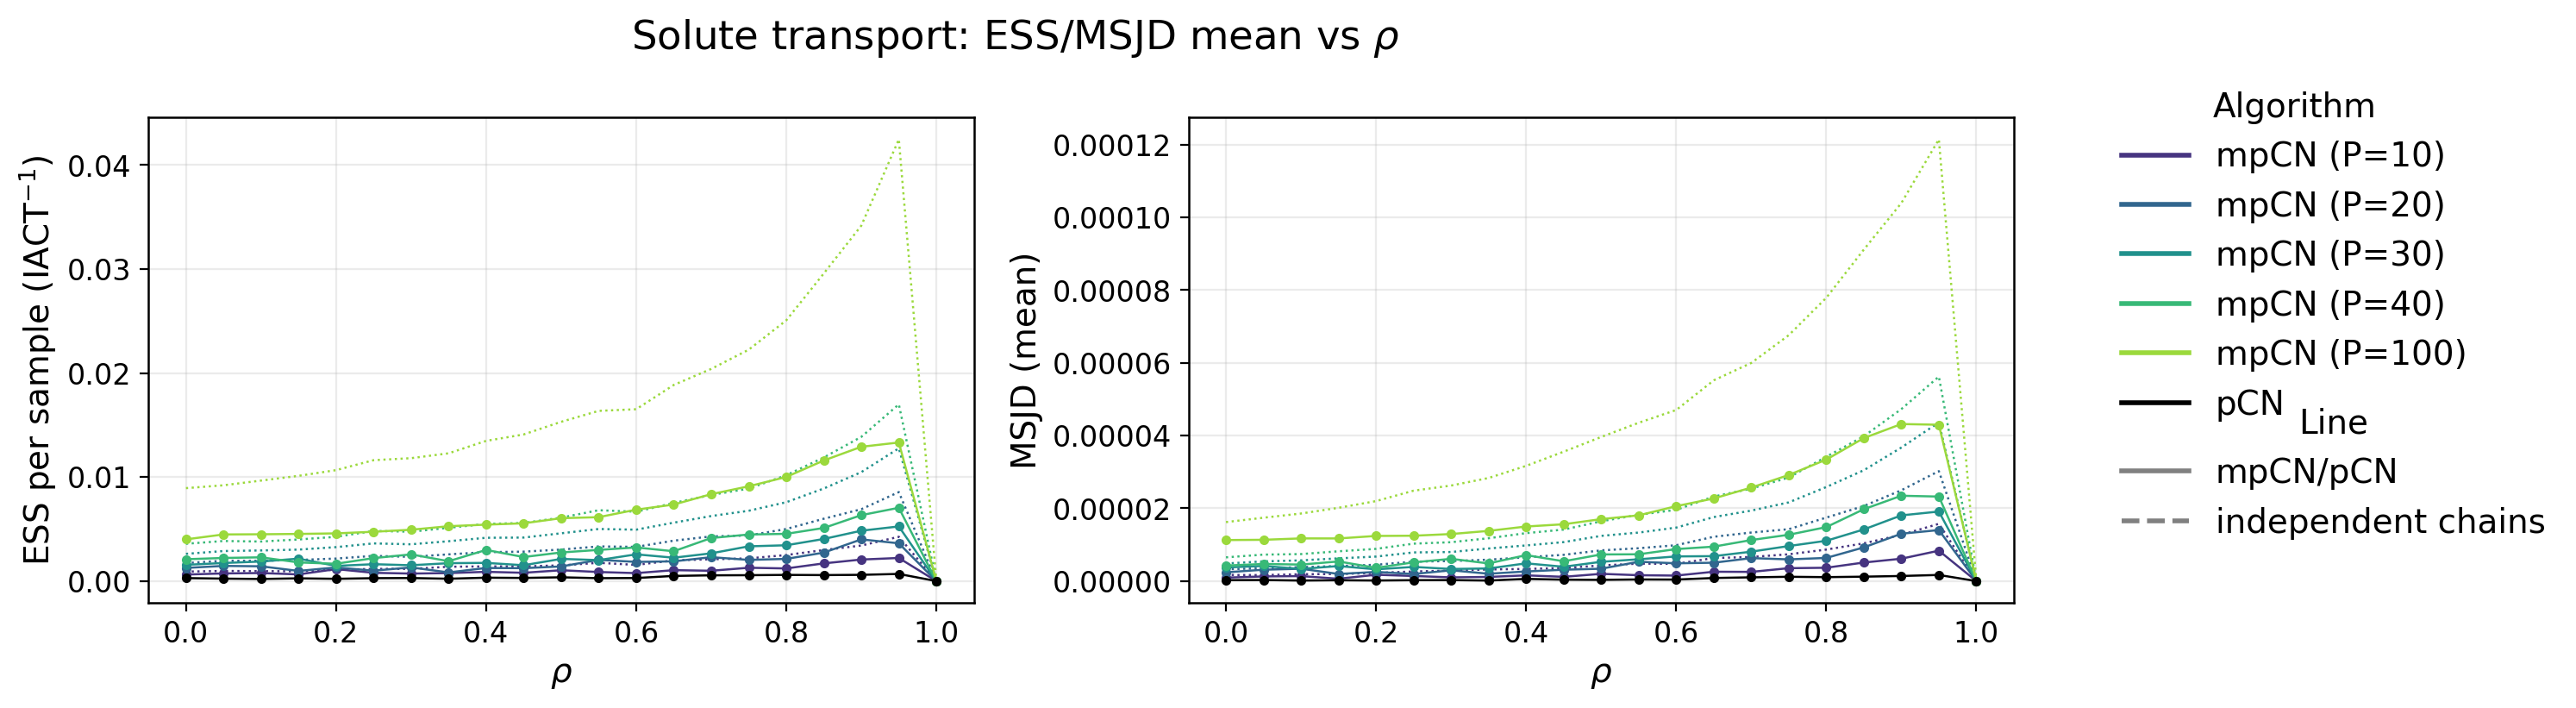

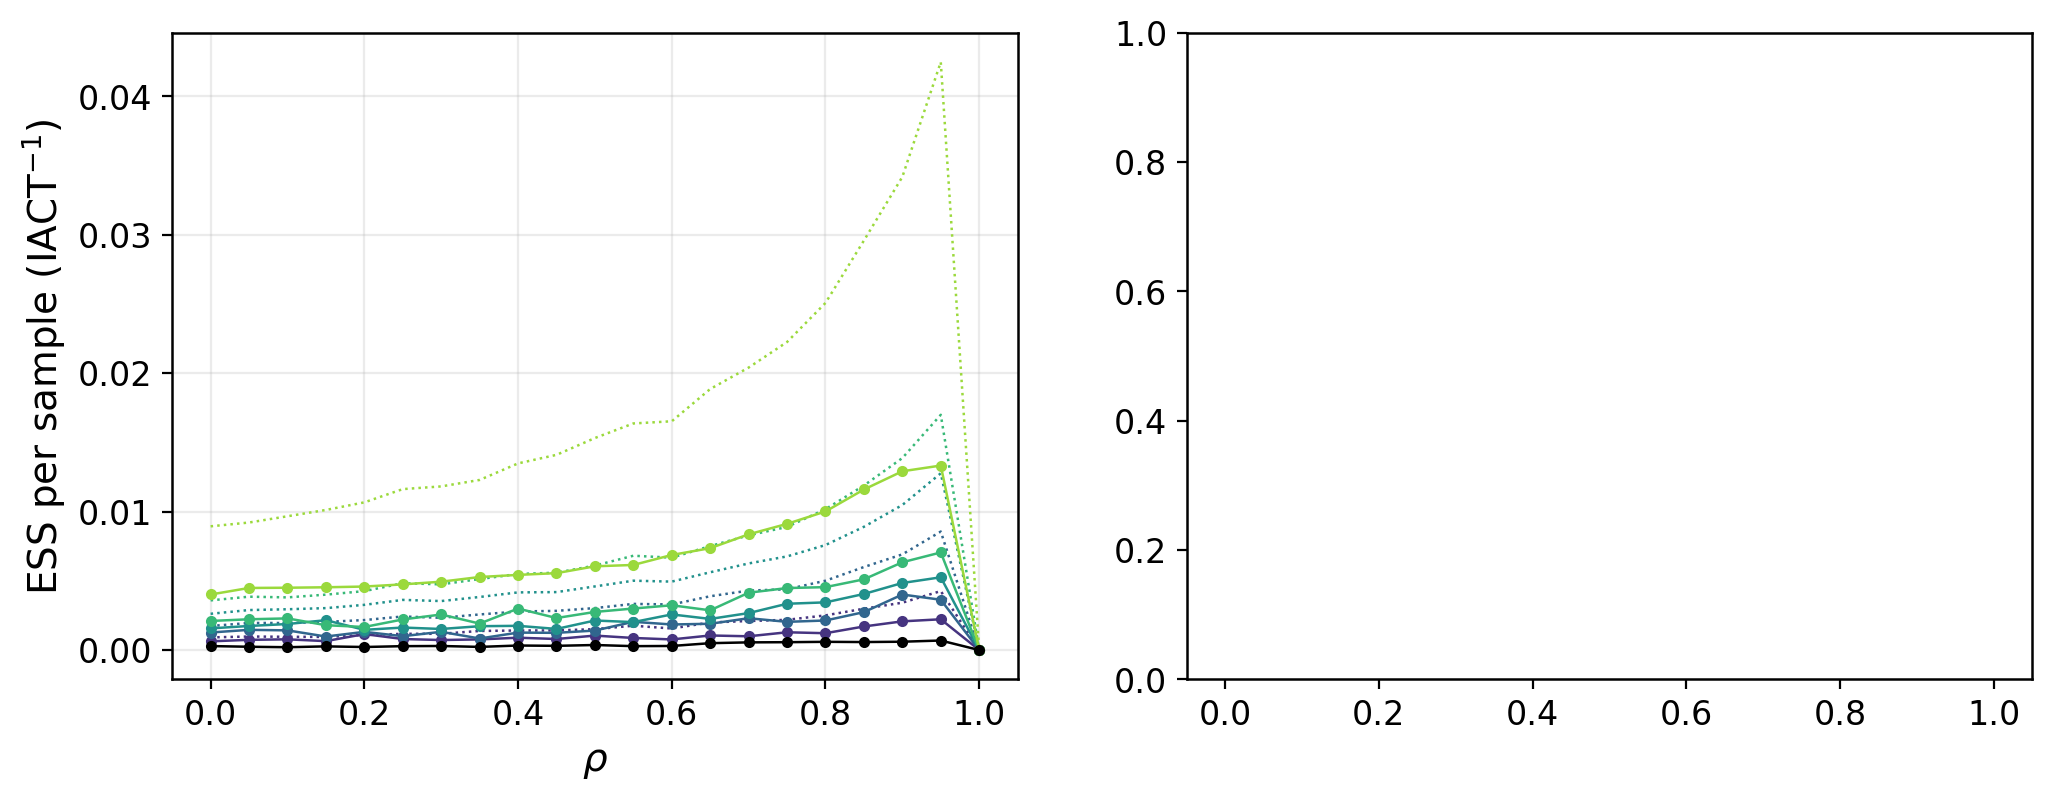

In [61]:
# ESS/MSJD vs rho curves (one line per P)
plot_ess_msjd_vs_rho(
    results,
    rho_list=rho_list,
    P_list=[x for x in P_list if x <= 100],
    reports_dir=reports_dir,
    seed_base=seed_base,
    file_name_fmt="solute_transport_ess_msjd_vs_rho_seed{seed_base}.png",
    run_pcn=run_pcn,
    run_mess=run_mess,
    burn_in=burn_in,
    show_mess=False,
    show_pcn=True,
    title_prefix="Solute transport",
    normalize_ess=True,
    share_y_metrics=False,
    show_independent=True,
    independent_label_prefix="pCN indep",
)

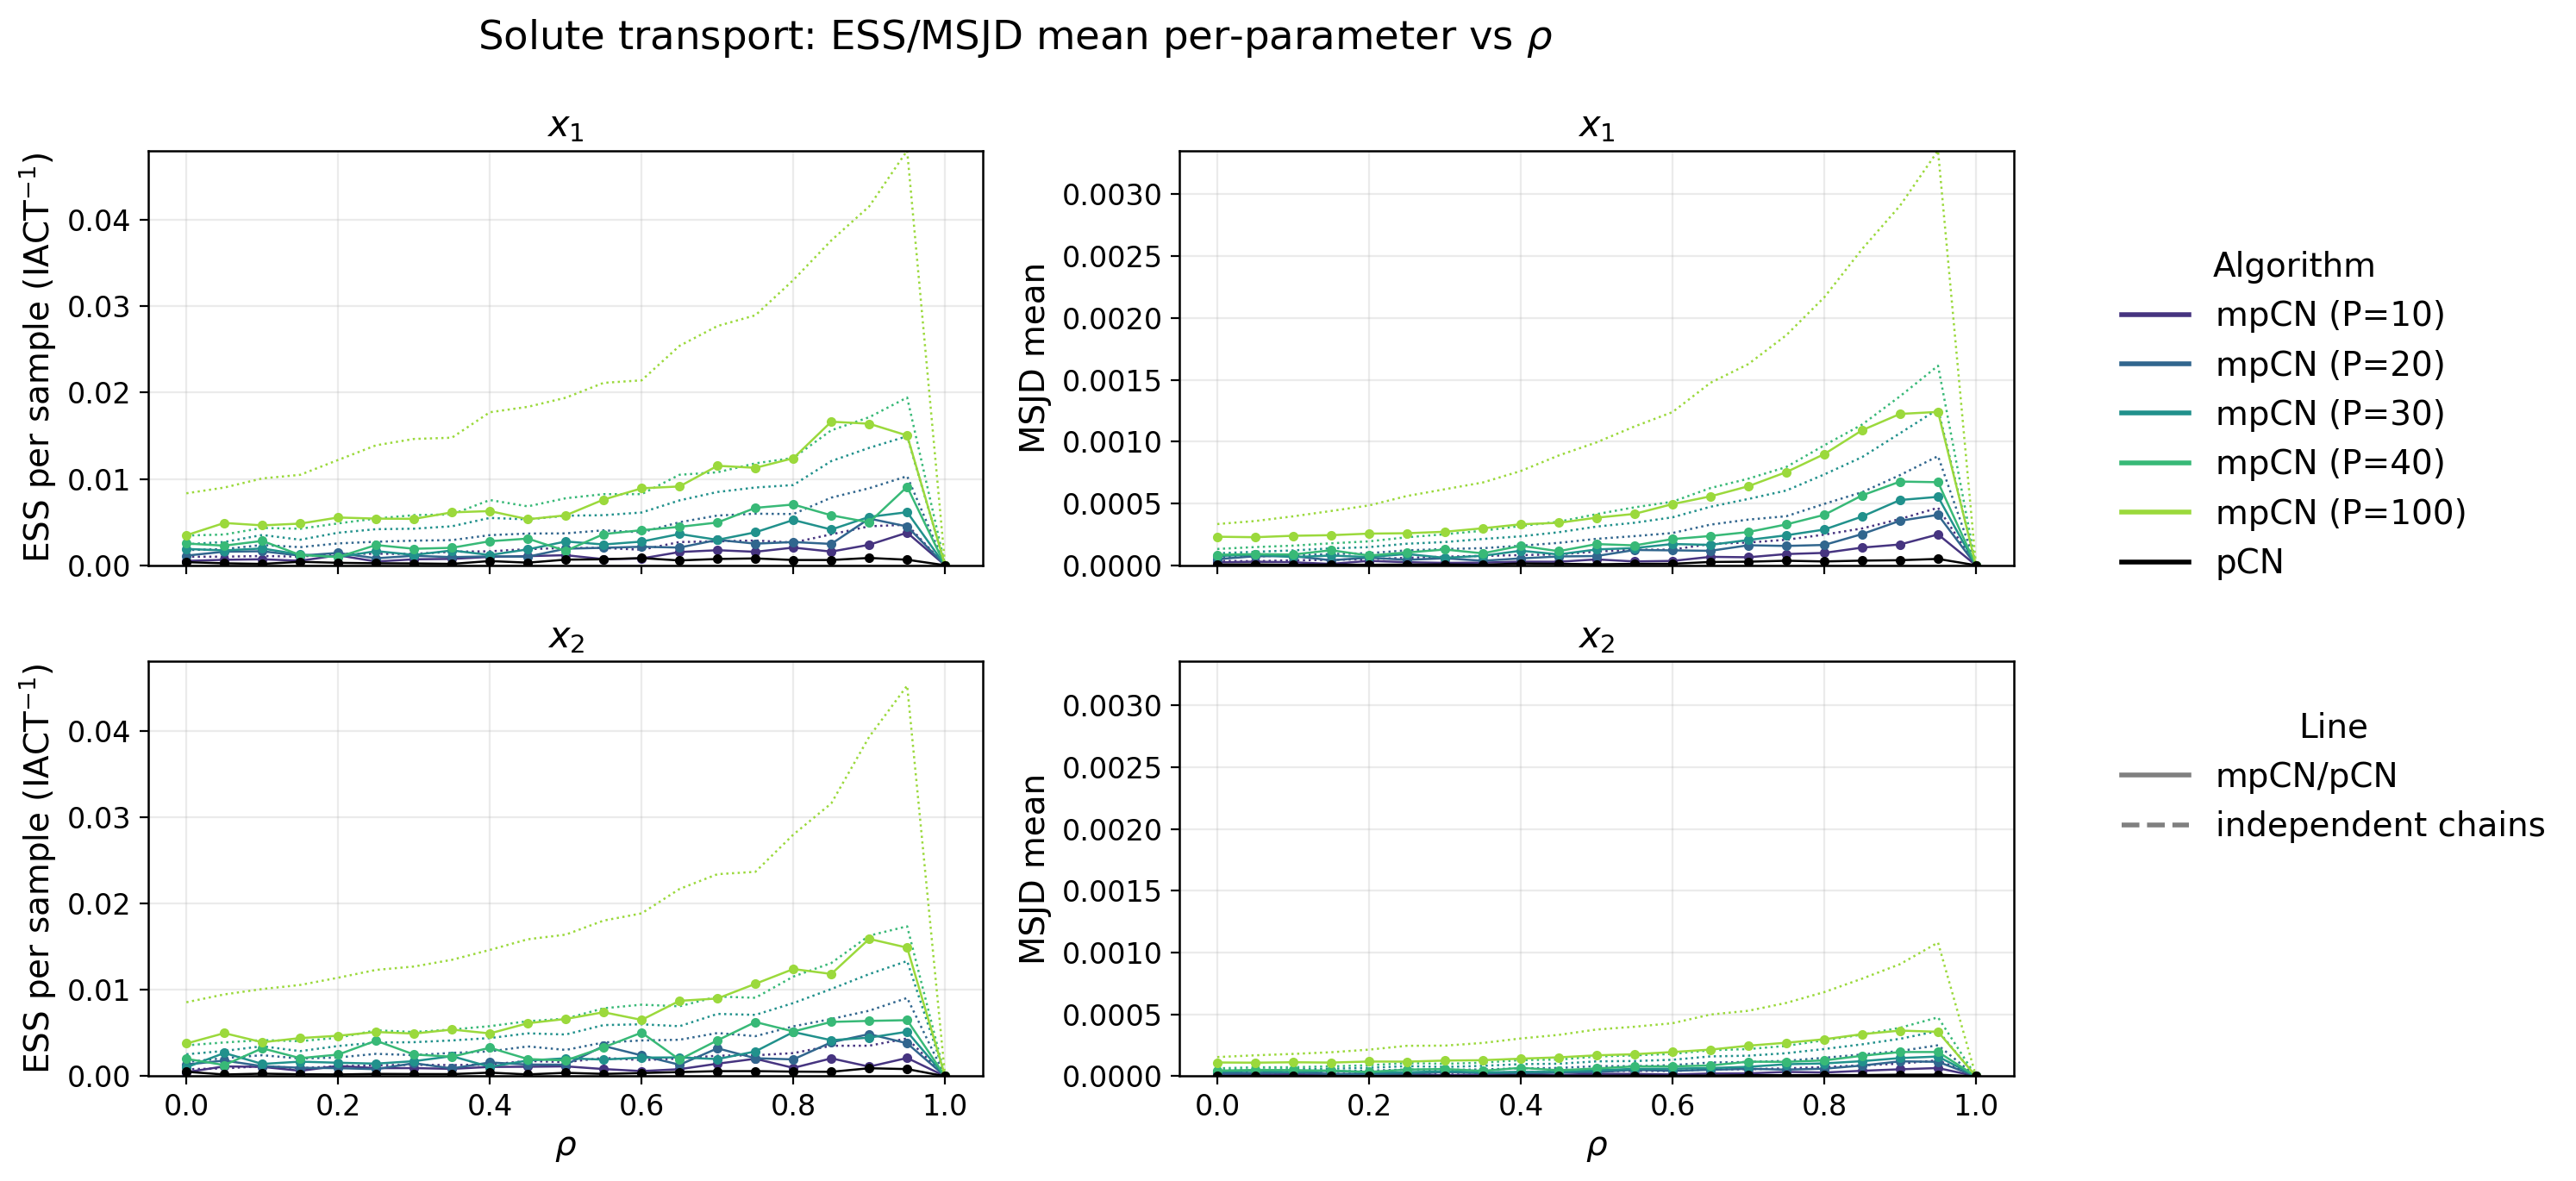

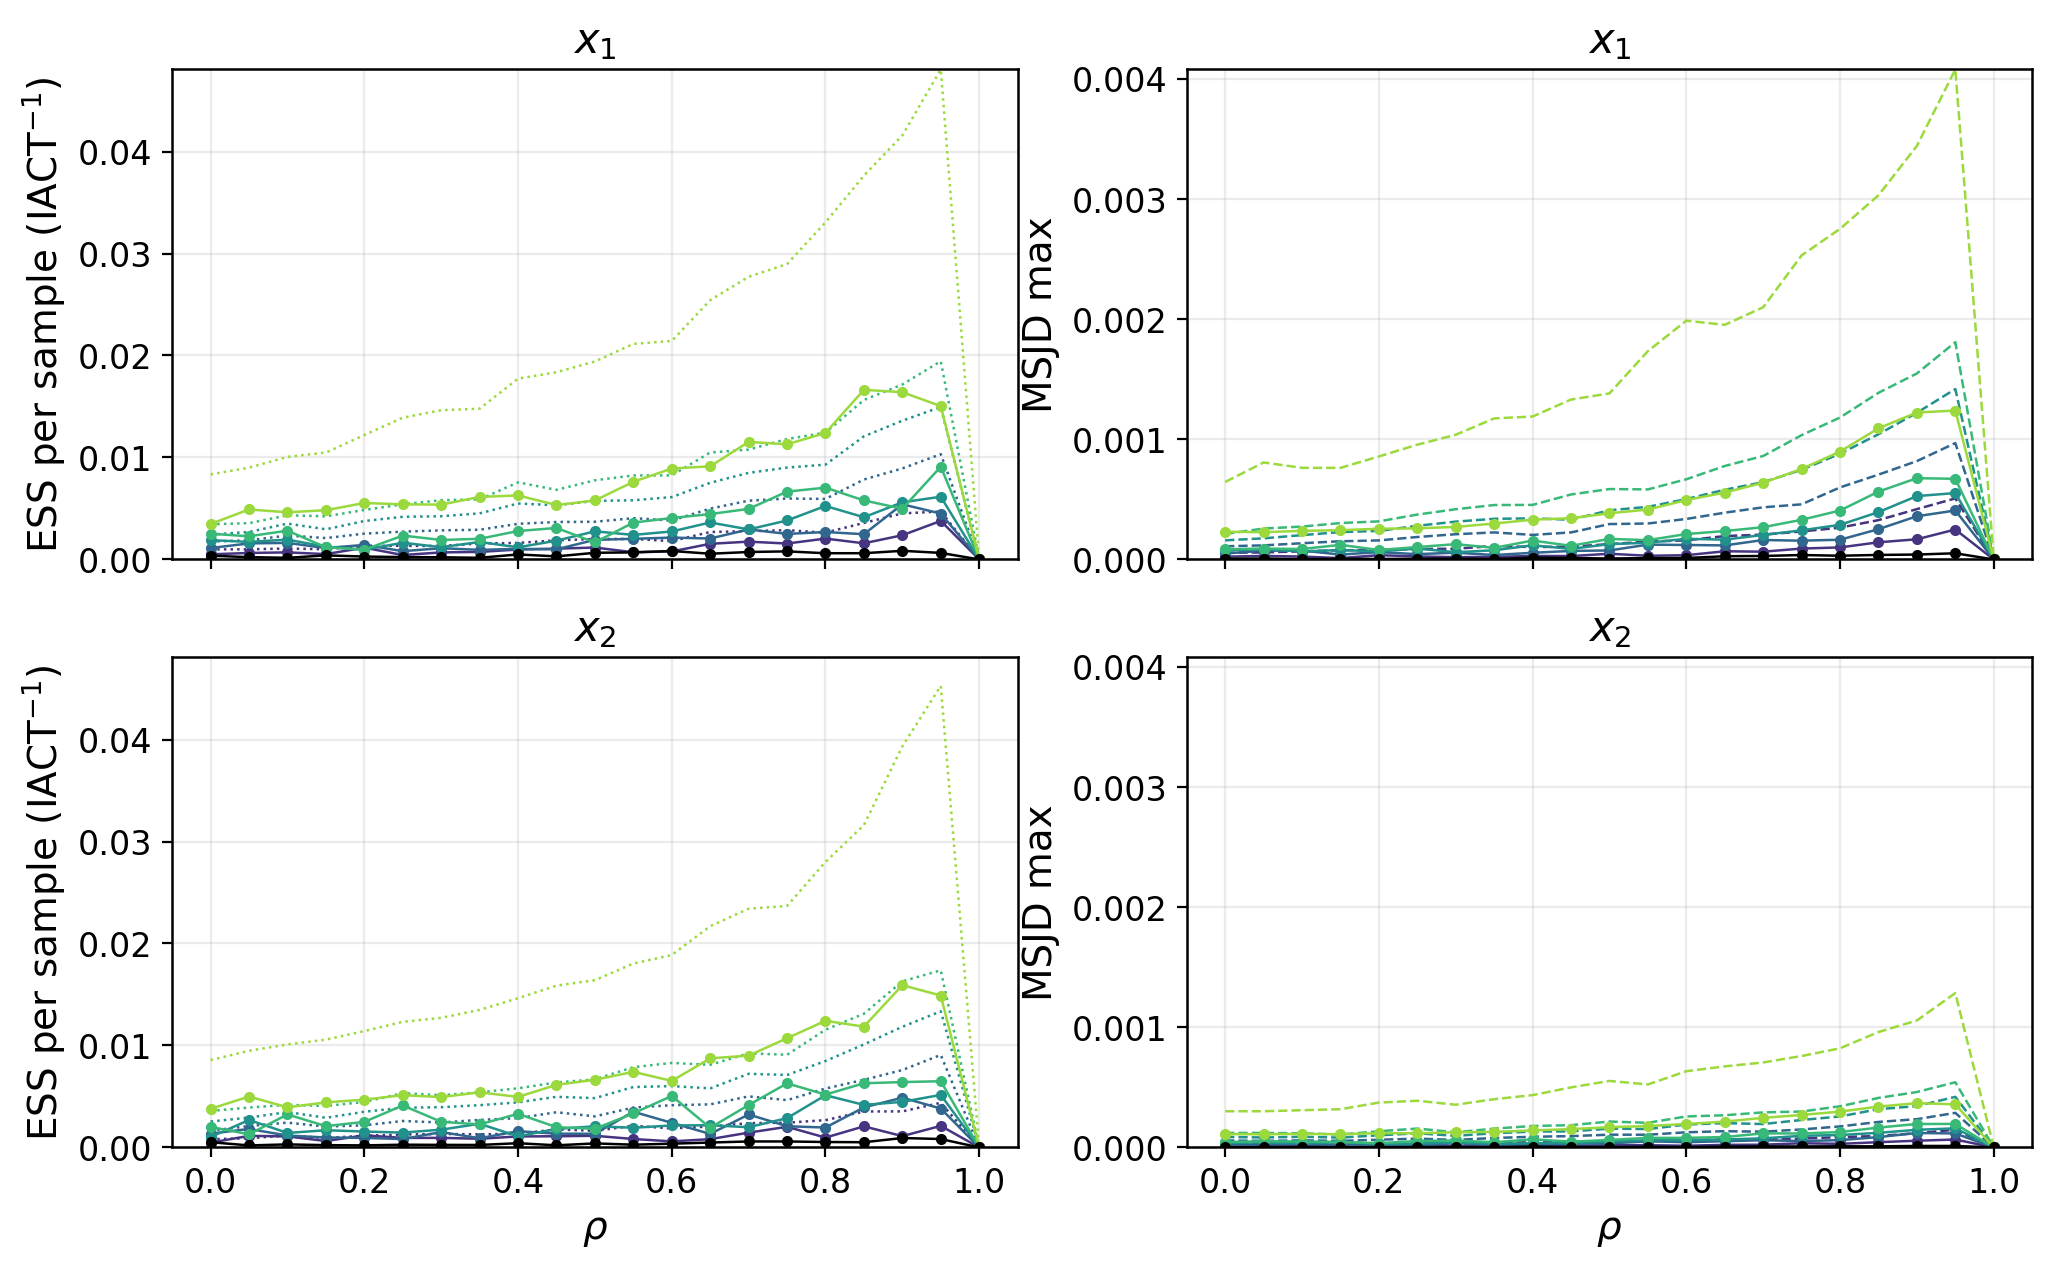

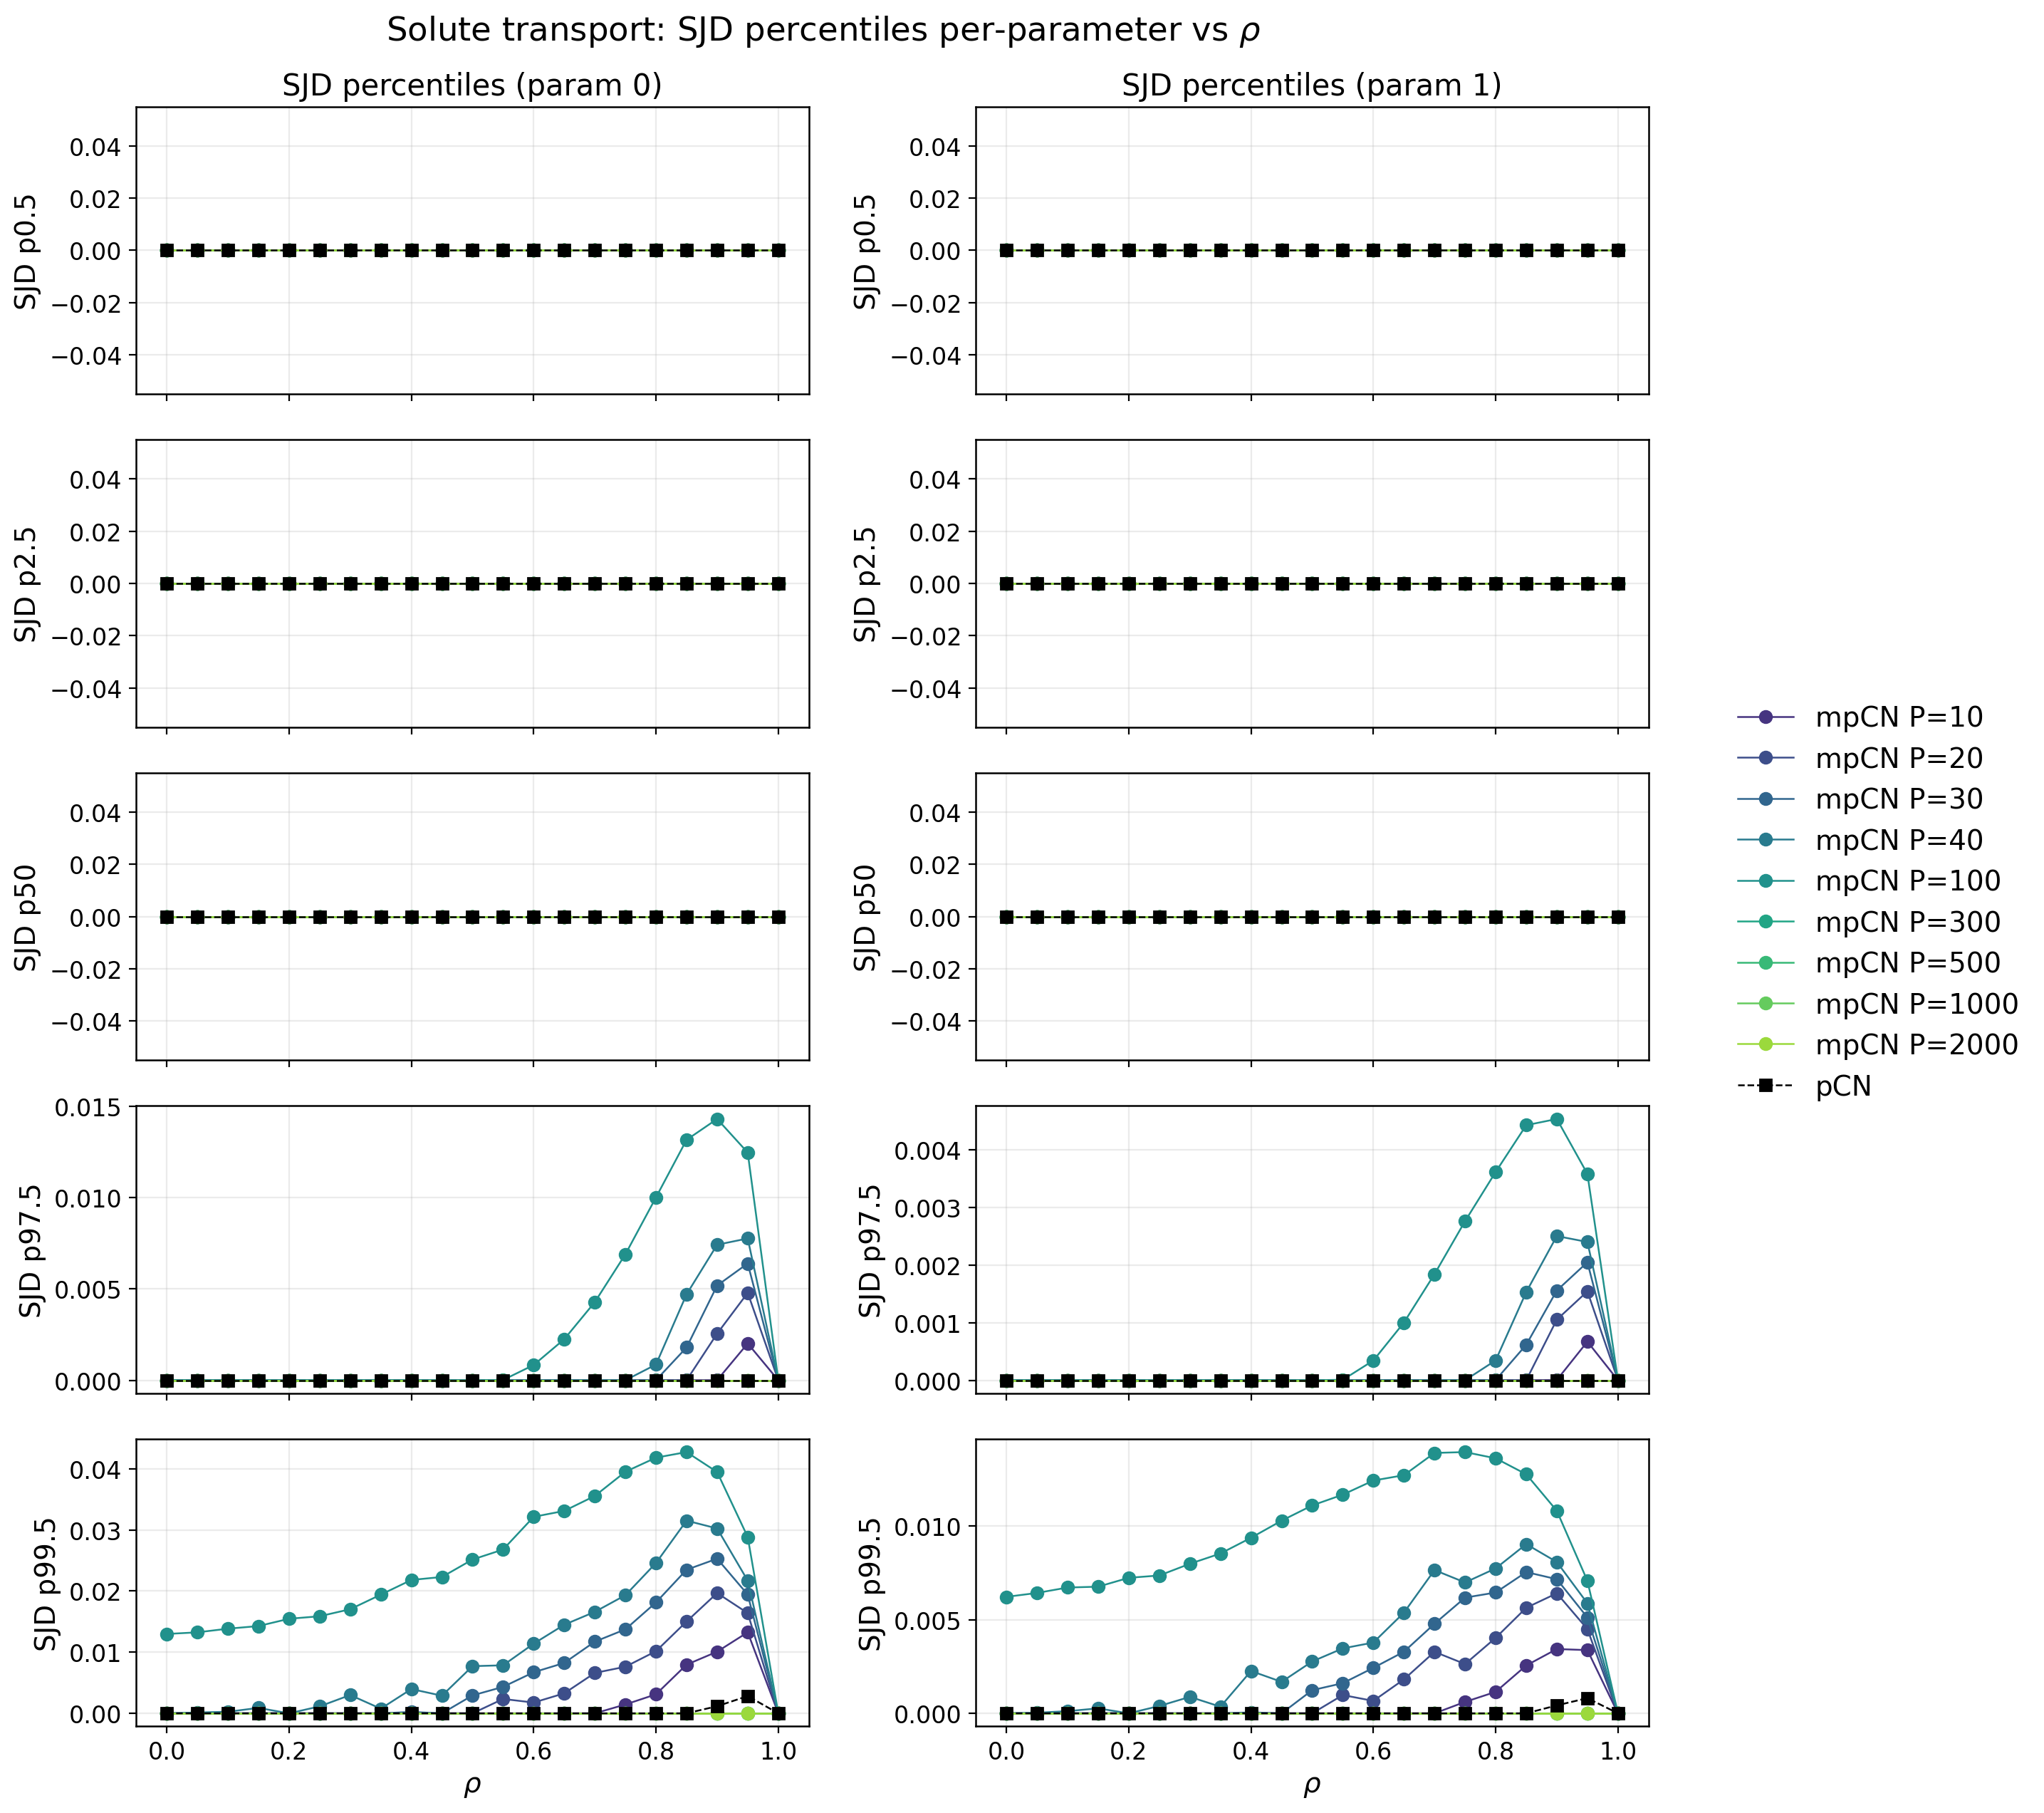

In [63]:
# ESS/MSJD per-parameter vs rho (full range + edges)
plot_ess_msjd_per_param_vs_rho(
    results,
    rho_list=rho_list,
    P_list=P_list,
    reports_dir=reports_dir,
    seed_base=seed_base,
    file_name_fmt="solute_transport_ess_msjd_per_param_vs_rho_seed{seed_base}.png",
    run_pcn=run_pcn,
    burn_in=burn_in,
    show_pcn=True,
    title_prefix="Solute transport",
    pcn_scale=None,
    normalize_ess=True,
    share_y_metrics=True,
    show_independent=True,
    independent_label_prefix="pCN indep",
)

percentiles = [
    ('p0.5', '0.5'),
    ('p2.5', '2.5'),
    ('p50', '50'),
    ('p97.5', '97.5'),
    ('p99.5', '99.5'),
]
nrows = len(percentiles)
fig, axes = plt.subplots(nrows, 2, figsize=(12.0, 2.6 * nrows), sharex=True)
axes = np.array(axes)
if axes.ndim == 1:
    axes = axes[None, :]

for row_idx, (key, label) in enumerate(percentiles):
    for P in P_sorted:
        sjd_p0 = [get_sjd_percentile(results['mpcn'], P, rho, 0, key) for rho in rho_list]
        sjd_p1 = [get_sjd_percentile(results['mpcn'], P, rho, 1, key) for rho in rho_list]
        axes[row_idx, 0].plot(rho_list, sjd_p0, marker='o', color=color_by_P[P], label=f'mpCN P={P}')
        axes[row_idx, 1].plot(rho_list, sjd_p1, marker='o', color=color_by_P[P])
    if show_pcn and run_pcn and results['pcn']:
        pcn_sjd_p0 = [get_sjd_percentile(results['pcn'], None, rho, 0, key) for rho in rho_list]
        pcn_sjd_p1 = [get_sjd_percentile(results['pcn'], None, rho, 1, key) for rho in rho_list]
        axes[row_idx, 0].plot(rho_list, pcn_sjd_p0, color='black', marker='s', linestyle='--', label='pCN')
        axes[row_idx, 1].plot(rho_list, pcn_sjd_p1, color='black', marker='s', linestyle='--')
    axes[row_idx, 0].set_ylabel(f'SJD p{label}')
    axes[row_idx, 1].set_ylabel(f'SJD p{label}')
    axes[row_idx, 0].grid(alpha=0.25)
    axes[row_idx, 1].grid(alpha=0.25)

axes[0, 0].set_title('SJD percentiles (param 0)')
axes[0, 1].set_title('SJD percentiles (param 1)')
for ax in axes[-1, :]:
    ax.set_xlabel(r'$\rho$')

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
fig.suptitle(r'Solute transport: SJD percentiles per-parameter vs $\rho$')
fig.tight_layout()
fig.savefig(
    reports_dir / f'solute_transport_sjd_percentiles_per_param_vs_rho_seed{seed_base}.png',
    bbox_inches='tight',
)
plt.show()

P=10: ESS p70=47.34 -> 6/21 rho (strict >)
  ESS values by rho: [('0.000', '28.35'), ('0.050', '33.14'), ('0.100', '34.84'), ('0.150', '28.97'), ('0.200', '51.91'), ('0.250', '35.82'), ('0.300', '32.55'), ('0.350', '34.6'), ('0.400', '40.06'), ('0.450', '35.92'), ('0.500', '46.96'), ('0.550', '39.25'), ('0.600', '34.45'), ('0.650', '47.34'), ('0.700', '44.72'), ('0.750', '57.74'), ('0.800', '54.72'), ('0.850', '76.6'), ('0.900', '93.25'), ('0.950', '100'), ('1.000', '0')]
  ESS values only: ['28.35', '33.14', '34.84', '28.97', '51.91', '35.82', '32.55', '34.6', '40.06', '35.92', '46.96', '39.25', '34.45', '47.34', '44.72', '57.74', '54.72', '76.6', '93.25', '100', '0']
P=10: MSJD p70=2.531e-06 -> 6/21 rho (strict >)
  MSJD values by rho: [('0.000', '9.488e-07'), ('0.050', '1.282e-06'), ('0.100', '1.374e-06'), ('0.150', '6.457e-07'), ('0.200', '1.747e-06'), ('0.250', '1.405e-06'), ('0.300', '1.023e-06'), ('0.350', '1.144e-06'), ('0.400', '1.576e-06'), ('0.450', '1.172e-06'), ('0.500', '

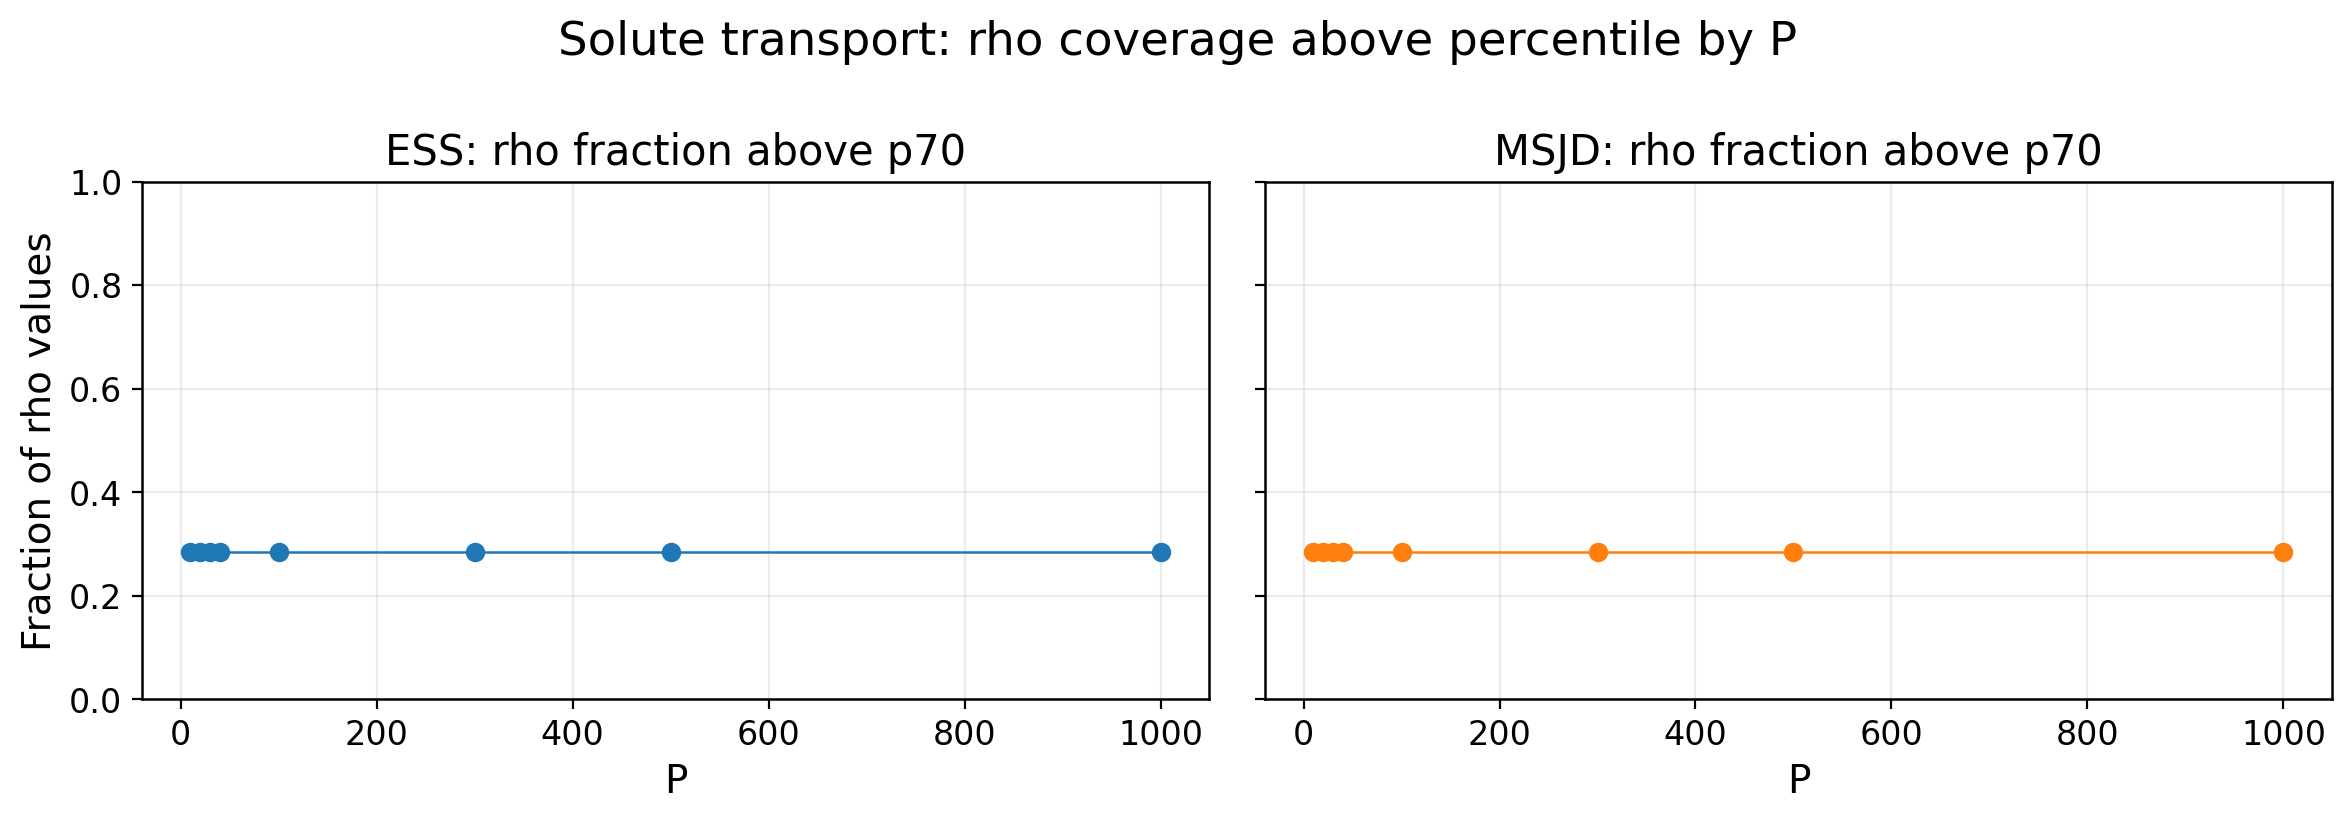

In [54]:
# Fraction of rho values above percentile (ESS/MSJD) vs P
apply_pub_style()

P_candidates = sorted([P for P in results.get('mpcn', {}).keys() if isinstance(P, (int, np.integer))])
P_plot = [P for P in P_candidates if P <= 2000]
percentile = 70.0
debug_print = True

def _collect_metric_over_rho(P, metric_key):
    values = []
    for rho in rho_list:
        entry = results.get('mpcn', {}).get(P, {}).get(float(rho))
        if entry is None:
            values.append(np.nan)
            continue
        metrics = entry.get('metrics', {})
        value = metrics.get(metric_key, np.nan)
        values.append(np.nan if value is None else value)
    return np.asarray(values, dtype=float)

def _rho_fraction_above_percentile(values, percentile):
    mask = np.isfinite(values)
    if not np.any(mask):
        return np.nan, np.nan, 0, 0
    finite = values[mask]
    threshold = float(np.nanpercentile(finite, percentile))
    count_above = int(np.sum(finite > threshold))
    count_total = int(finite.size)
    return float(count_above / count_total), float(threshold), count_above, count_total

ess_fraction = []
msjd_fraction = []
for P in P_plot:
    ess_vals = _collect_metric_over_rho(P, 'ess_mean')
    msjd_vals = _collect_metric_over_rho(P, 'msjd_mean')
    ess_frac, ess_thresh, ess_above, ess_total = _rho_fraction_above_percentile(ess_vals, percentile)
    msjd_frac, msjd_thresh, msjd_above, msjd_total = _rho_fraction_above_percentile(msjd_vals, percentile)
    ess_fraction.append(ess_frac)
    msjd_fraction.append(msjd_frac)
    if debug_print:
        rho_vals = np.asarray(rho_list, dtype=float)
        ess_mask = np.isfinite(ess_vals)
        msjd_mask = np.isfinite(msjd_vals)
        ess_pairs = list(zip(rho_vals[ess_mask], ess_vals[ess_mask]))
        msjd_pairs = list(zip(rho_vals[msjd_mask], msjd_vals[msjd_mask]))
        ess_pairs = sorted(ess_pairs, key=lambda item: item[0])
        msjd_pairs = sorted(msjd_pairs, key=lambda item: item[0])
        ess_values = [val for _, val in ess_pairs]
        msjd_values = [val for _, val in msjd_pairs]
        print(f'P={P}: ESS p{percentile:g}={ess_thresh:.4g} -> {ess_above}/{ess_total} rho (strict >)')
        print('  ESS values by rho:', [(f'{rho:.3f}', f'{val:.4g}') for rho, val in ess_pairs])
        print('  ESS values only:', [f'{val:.4g}' for val in ess_values])
        print(f'P={P}: MSJD p{percentile:g}={msjd_thresh:.4g} -> {msjd_above}/{msjd_total} rho (strict >)')
        print('  MSJD values by rho:', [(f'{rho:.3f}', f'{val:.4g}') for rho, val in msjd_pairs])
        print('  MSJD values only:', [f'{val:.4g}' for val in msjd_values])

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.2), sharex=True, sharey=True)
ax_ess, ax_msjd = axes

ax_ess.plot(P_plot, ess_fraction, marker='o', color='tab:blue')
ax_msjd.plot(P_plot, msjd_fraction, marker='o', color='tab:orange')

ax_ess.set_title(f'ESS: rho fraction above p{percentile:g}')
ax_msjd.set_title(f'MSJD: rho fraction above p{percentile:g}')
for ax in axes:
    ax.set_xlabel('P')
    ax.set_ylim(0.0, 1.0)
    ax.grid(alpha=0.25)
ax_ess.set_ylabel('Fraction of rho values')

fig.suptitle('Solute transport: rho coverage above percentile by P')
fig.tight_layout()
fig.savefig(
    reports_dir / f'solute_transport_rho_fraction_p{int(percentile)}_vs_P_seed{seed_base}.png',
    bbox_inches='tight',
    dpi=300,
 )
plt.show()

P=10: ESS max=100 -> 3/21 rho within 25%
P=10: MSJD max=8.364e-06 -> 1/21 rho within 25%
P=20: ESS max=180.4 -> 2/21 rho within 25%
P=20: MSJD max=1.403e-05 -> 2/21 rho within 25%
P=30: ESS max=236.5 -> 3/21 rho within 25%
P=30: MSJD max=1.912e-05 -> 2/21 rho within 25%
P=40: ESS max=317.2 -> 2/21 rho within 25%
P=40: MSJD max=2.347e-05 -> 3/21 rho within 25%
P=100: ESS max=3931 -> 4/21 rho within 25%
P=100: MSJD max=4.318e-05 -> 4/21 rho within 25%
P=300: ESS max=8406 -> 6/21 rho within 25%
P=300: MSJD max=8.297e-05 -> 6/21 rho within 25%
P=500: ESS max=1.178e+04 -> 7/21 rho within 25%
P=500: MSJD max=0.0001118 -> 7/21 rho within 25%
P=1000: ESS max=1.915e+04 -> 11/21 rho within 25%
P=1000: MSJD max=0.0001603 -> 10/21 rho within 25%


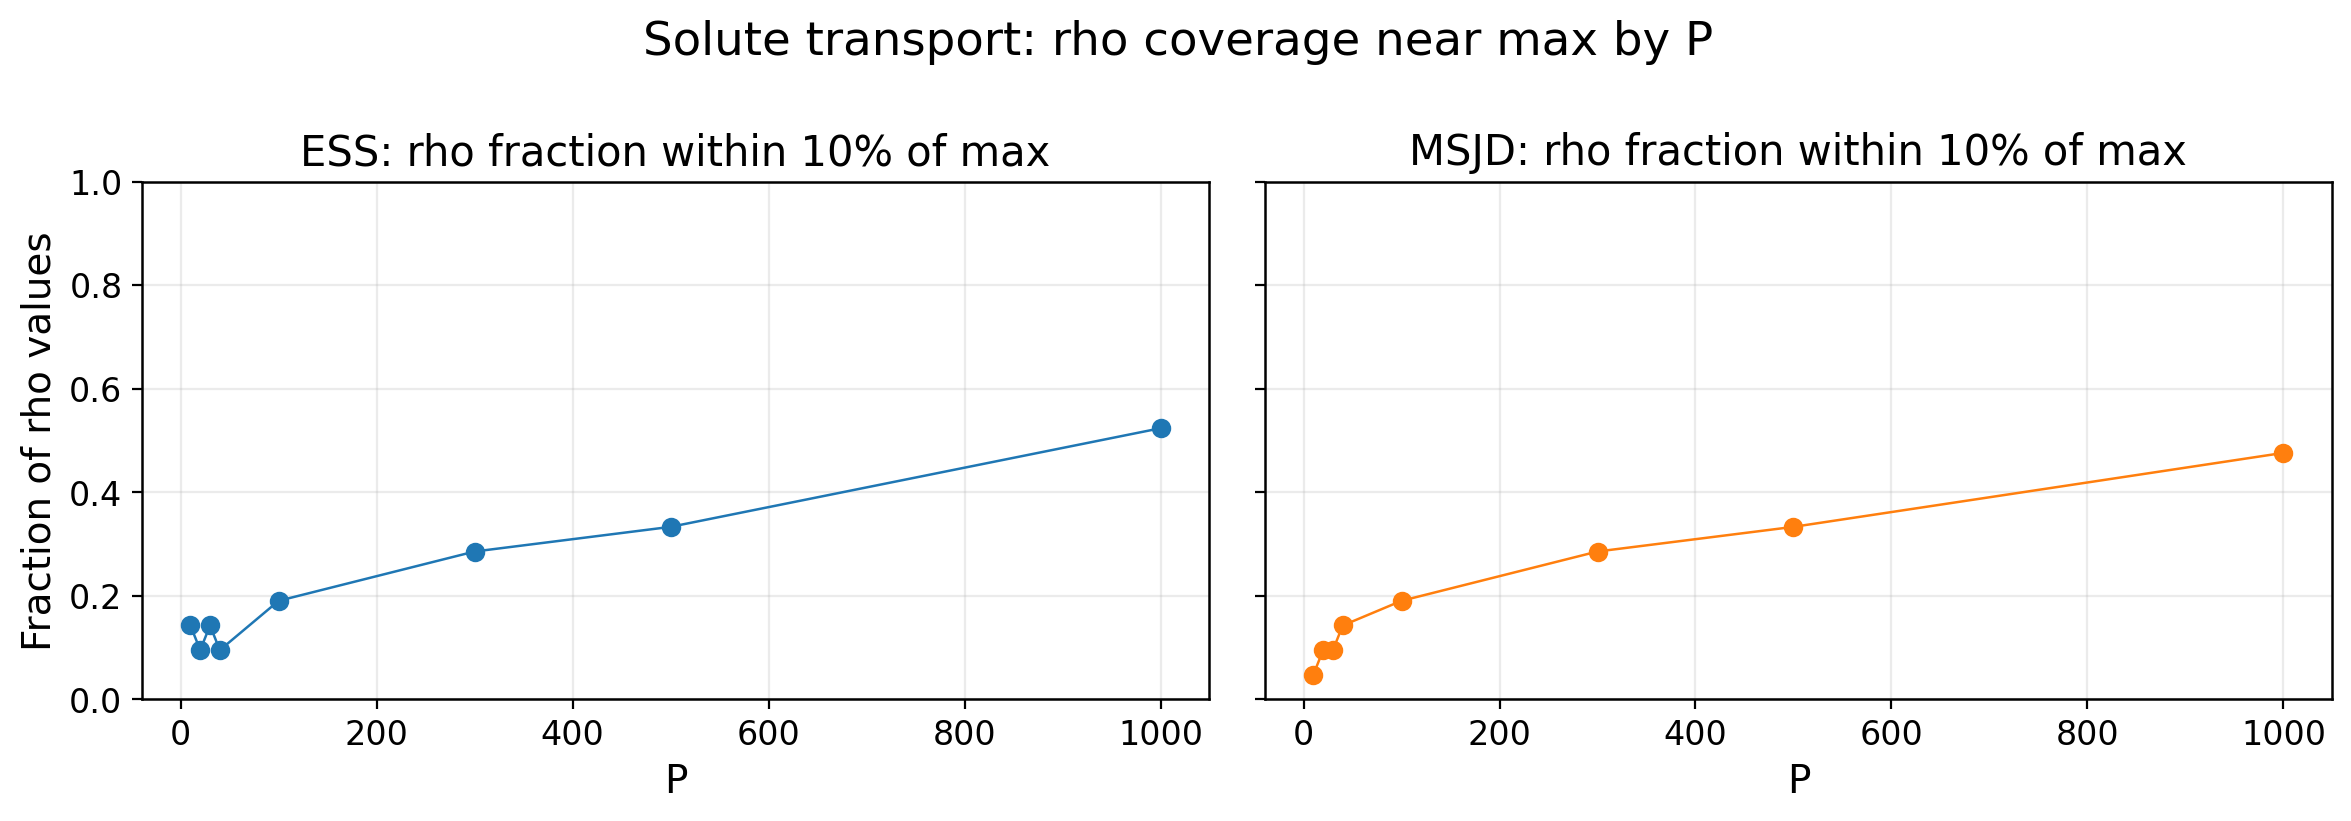

In [57]:
# Fraction of rho values within 10% of max (ESS/MSJD) vs P
apply_pub_style()

P_candidates = sorted([P for P in results.get('mpcn', {}).keys() if isinstance(P, (int, np.integer))])
P_plot = [P for P in P_candidates if P <= 2000]
debug_print = True
tolerance = 0.25

def _collect_metric_over_rho(P, metric_key):
    values = []
    for rho in rho_list:
        entry = results.get('mpcn', {}).get(P, {}).get(float(rho))
        if entry is None:
            values.append(np.nan)
            continue
        metrics = entry.get('metrics', {})
        value = metrics.get(metric_key, np.nan)
        values.append(np.nan if value is None else value)
    return np.asarray(values, dtype=float)

def _rho_fraction_within_max(values, tolerance):
    mask = np.isfinite(values)
    if not np.any(mask):
        return np.nan, np.nan, 0, 0
    finite = values[mask]
    max_val = float(np.nanmax(finite))
    if max_val == 0.0:
        within = finite == 0.0
    else:
        lower = max_val * (1.0 - tolerance)
        within = finite >= lower
    count_within = int(np.sum(within))
    count_total = int(finite.size)
    return float(count_within / count_total), max_val, count_within, count_total

ess_fraction = []
msjd_fraction = []
for P in P_plot:
    ess_vals = _collect_metric_over_rho(P, 'ess_mean')
    msjd_vals = _collect_metric_over_rho(P, 'msjd_mean')
    ess_frac, ess_max, ess_within, ess_total = _rho_fraction_within_max(ess_vals, tolerance)
    msjd_frac, msjd_max, msjd_within, msjd_total = _rho_fraction_within_max(msjd_vals, tolerance)
    ess_fraction.append(ess_frac)
    msjd_fraction.append(msjd_frac)
    if debug_print:
        print(f'P={P}: ESS max={ess_max:.4g} -> {ess_within}/{ess_total} rho within {tolerance:.0%}')
        print(f'P={P}: MSJD max={msjd_max:.4g} -> {msjd_within}/{msjd_total} rho within {tolerance:.0%}')

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.2), sharex=True, sharey=True)
ax_ess, ax_msjd = axes

ax_ess.plot(P_plot, ess_fraction, marker='o', color='tab:blue')
ax_msjd.plot(P_plot, msjd_fraction, marker='o', color='tab:orange')

ax_ess.set_title('ESS: rho fraction within 10% of max')
ax_msjd.set_title('MSJD: rho fraction within 10% of max')
for ax in axes:
    ax.set_xlabel('P')
    ax.set_ylim(0.0, 1.0)
    ax.grid(alpha=0.25)
ax_ess.set_ylabel('Fraction of rho values')

fig.suptitle('Solute transport: rho coverage near max by P')
fig.tight_layout()
fig.savefig(
    reports_dir / f'solute_transport_rho_fraction_within10pct_max_vs_P_seed{seed_base}.png',
    bbox_inches='tight',
    dpi=300,
 )
plt.show()

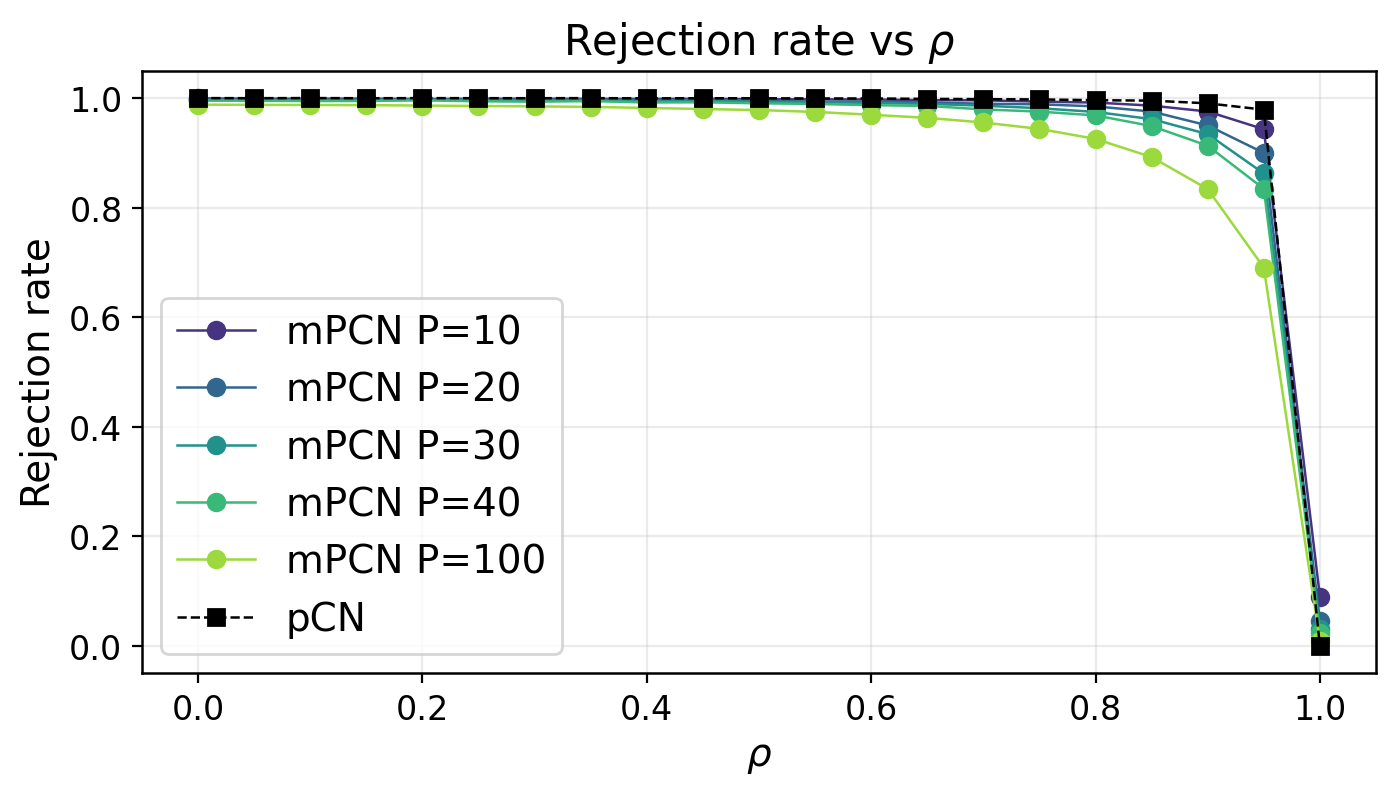

In [64]:
# Rejection rate vs rho (one line per P)
apply_pub_style()

P_sorted = sorted(P_list)
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(P_sorted)))
color_by_P = {P: colors[i] for i, P in enumerate(P_sorted)}
show_pcn = True

def get_accept_rate(results_dict, P, rho, default=0.0):
    if P is None:
        entry = results_dict.get(float(rho))
    else:
        entry = results_dict.get(P)
        if isinstance(entry, dict):
            entry = entry.get(float(rho))
    if not isinstance(entry, dict):
        return default
    accept_rate = entry.get('accept_rate')
    return default if accept_rate is None else accept_rate

pcn_reject = None
if run_pcn and results['pcn']:
    pcn_reject = [1.0 - get_accept_rate(results['pcn'], None, rho, default=0.0) for rho in rho_list]

fig, ax = plt.subplots(1, 1, figsize=(7.2, 4.2), sharex=True)

for P in P_sorted:
    reject_vals = [1.0 - get_accept_rate(results['mpcn'], P, rho, default=0.0) for rho in rho_list]
    ax.plot(rho_list, reject_vals, marker='o', color=color_by_P[P], label=f'mPCN P={P}')
if show_pcn and pcn_reject is not None:
    ax.plot(rho_list, pcn_reject, color='black', marker='s', linestyle='--', label='pCN')

ax.set_xlabel(r'$\rho$')
ax.set_ylabel('Rejection rate')
ax.set_title(r'Rejection rate vs $\rho$')
ax.grid(alpha=0.25)
ax.legend(loc='best')

fig.tight_layout()
fig.savefig(reports_dir / f'solute_transport_rejection_vs_rho_seed{seed_base}.png', bbox_inches='tight')
plt.show()

In [65]:
# ESS/MSJD tables (rows=P, columns=rho + pCN)
def get_metric_table_value(results_dict, P, rho, metric_key, default=0.0):
    if P is None:
        entry = results_dict.get(float(rho))
    else:
        entry = results_dict.get(P)
        if isinstance(entry, dict):
            entry = entry.get(float(rho))
    if not isinstance(entry, dict):
        return default
    value = entry['metrics'].get(metric_key)
    return default if value is None else value


ess_rows = []
msjd_rows = []
row_labels = []
col_labels = [f'rho={rho:.3f}' for rho in rho_list]

for P in P_list:
    ess_row = [get_metric_table_value(results['mpcn'], P, rho, 'ess_mean') for rho in rho_list]
    msjd_row = [get_metric_table_value(results['mpcn'], P, rho, 'msjd_mean') for rho in rho_list]
    ess_rows.append(ess_row)
    msjd_rows.append(msjd_row)
    row_labels.append(f'P={P}')

if run_pcn and results['pcn']:
    ess_row = [get_metric_table_value(results['pcn'], None, rho, 'ess_mean') for rho in rho_list]
    msjd_row = [get_metric_table_value(results['pcn'], None, rho, 'msjd_mean') for rho in rho_list]
    ess_rows.append(ess_row)
    msjd_rows.append(msjd_row)
    row_labels.append('pCN')

if run_independent_pcn and results['pcn_independent']:
    for P in sorted(results['pcn_independent'].keys()):
        ess_row = [
            get_metric_table_value(results['pcn_independent'], P, rho, 'ess_mean_sum')
            for rho in rho_list
        ]
        msjd_row = [
            get_metric_table_value(results['pcn_independent'], P, rho, 'msjd_mean_mean')
            for rho in rho_list
        ]
        ess_rows.append(ess_row)
        msjd_rows.append(msjd_row)
        row_labels.append(f'pCN indep P={P}')

ess_table = pd.DataFrame(ess_rows, index=row_labels, columns=col_labels)
msjd_table = pd.DataFrame(msjd_rows, index=row_labels, columns=col_labels)

ess_table_display = ess_table.round(0).astype(int)
msjd_table_display = msjd_table.round(3)
print('ESS table (mpCN across rho; pCN/indep rows if enabled):')
display(ess_table_display)
print('MSJD table (mpCN across rho; pCN/indep rows if enabled):')
display(msjd_table_display)

# SJD percentile tables per parameter
def _chain_param_view(chain, param_index):
    if chain.ndim == 1:
        return chain
    return chain[:, param_index]


def build_sjd_percentile_table(param_index):
    percentiles = (50.0, 2.5, 97.5, 0.5, 99.5)
    percentile_keys = ['p50', 'p2.5', 'p97.5', 'p0.5', 'p99.5']
    col_multi = pd.MultiIndex.from_product(
        [col_labels, percentile_keys],
        names=['rho', 'percentile'],
    )
    rows = []
    labels = []
    for P in P_list[:-1]:
        row = []
        for rho in rho_list:
            entry = results.get('mpcn', {}).get(P, {}).get(float(rho))
            if entry is None:
                row.extend([0.0] * len(percentile_keys))
                continue
            chain = entry['chain'][burn_in:]
            param_chain = _chain_param_view(chain, param_index)
            if param_chain.shape[0] < 2:
                row.extend([0.0] * len(percentile_keys))
                continue
            summary = summarize_squared_jumping_distance(
                param_chain,
                percentiles=percentiles,
                return_distribution=False,
            )
            row.extend([summary['percentiles'].get(key, 0.0) for key in percentile_keys])
        rows.append(row)
        labels.append(f'P={P}')

    if run_pcn and results['pcn']:
        row = []
        for rho in rho_list:
            entry = results.get('pcn', {}).get(float(rho))
            if entry is None:
                row.extend([0.0] * len(percentile_keys))
                continue
            chain = entry['chain'][burn_in:]
            param_chain = _chain_param_view(chain, param_index)
            if param_chain.shape[0] < 2:
                row.extend([0.0] * len(percentile_keys))
                continue
            summary = summarize_squared_jumping_distance(
                param_chain,
                percentiles=percentiles,
                return_distribution=False,
            )
            row.extend([summary['percentiles'].get(key, 0.0) for key in percentile_keys])
        rows.append(row)
        labels.append('pCN')

    table = pd.DataFrame(rows, index=labels, columns=col_multi)
    return table


sjd_table_param0 = build_sjd_percentile_table(0)
sjd_table_param1 = build_sjd_percentile_table(1)

print('SJD percentiles by rho (param 0):')
display(sjd_table_param0.round(4))
print('SJD percentiles by rho (param 1):')
display(sjd_table_param1.round(4))

ESS table (mpCN across rho; pCN/indep rows if enabled):


,rho=0.000,rho=0.050,rho=0.100,rho=0.150,rho=0.200,rho=0.250,rho=0.300,rho=0.350,rho=0.400,rho=0.450,...,rho=0.550,rho=0.600,rho=0.650,rho=0.700,rho=0.750,rho=0.800,rho=0.850,rho=0.900,rho=0.950,rho=1.000
P=10,28,33,35,29,52,36,33,35,40,36,...,39,34,47,45,58,55,77,93,100,0
P=20,57,66,64,44,59,45,59,37,57,56,...,92,83,85,103,92,96,123,180,163,0
P=30,70,78,85,97,66,73,68,78,79,69,...,91,116,101,120,150,155,182,218,236,0
P=40,95,100,103,81,75,99,116,86,135,104,...,135,146,129,186,202,204,230,285,317,0
P=100,1184,1323,1328,1337,1353,1399,1456,1556,1601,1639,...,1813,2026,2171,2466,2688,2953,3421,3809,3931,0
pCN,13,11,9,12,10,13,13,10,15,14,...,13,13,22,25,26,27,26,27,31,0
pCN indep P=10,269,288,282,279,320,346,347,407,416,418,...,518,459,588,619,644,739,881,1009,1257,0
pCN indep P=20,512,577,576,600,639,715,687,758,821,835,...,983,971,1146,1267,1294,1477,1769,2039,2525,0
pCN indep P=30,773,852,869,893,963,1069,1044,1131,1228,1235,...,1478,1458,1657,1845,1995,2237,2626,3091,3766,0
pCN indep P=40,1058,1137,1122,1181,1255,1424,1400,1512,1621,1648,...,2010,1968,2215,2444,2623,3002,3506,4091,5013,0


MSJD table (mpCN across rho; pCN/indep rows if enabled):


,rho=0.000,rho=0.050,rho=0.100,rho=0.150,rho=0.200,rho=0.250,rho=0.300,rho=0.350,rho=0.400,rho=0.450,...,rho=0.550,rho=0.600,rho=0.650,rho=0.700,rho=0.750,rho=0.800,rho=0.850,rho=0.900,rho=0.950,rho=1.000
P=10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
P=20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
P=30,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
P=40,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
P=100,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
pCN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
pCN indep P=10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
pCN indep P=20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
pCN indep P=30,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
pCN indep P=40,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


SJD percentiles by rho (param 0):


rho        rho=0.000                       rho=0.050                          \
percentile       p50 p2.5 p97.5 p0.5 p99.5       p50 p2.5 p97.5 p0.5   p99.5   
P=10             0.0  0.0   0.0  0.0   0.0       0.0  0.0   0.0  0.0  0.0000   
P=20             0.0  0.0   0.0  0.0   0.0       0.0  0.0   0.0  0.0  0.0000   
P=30             0.0  0.0   0.0  0.0   0.0       0.0  0.0   0.0  0.0  0.0000   
P=40             0.0  0.0   0.0  0.0   0.0       0.0  0.0   0.0  0.0  0.0001   
pCN              0.0  0.0   0.0  0.0   0.0       0.0  0.0   0.0  0.0  0.0000   

rho         ... rho=0.950                           rho=1.000                  \
percentile  ...       p50 p2.5   p97.5 p0.5   p99.5       p50 p2.5 p97.5 p0.5   
P=10        ...       0.0  0.0  0.0020  0.0  0.0133       0.0  0.0   0.0  0.0   
P=20        ...       0.0  0.0  0.0048  0.0  0.0164       0.0  0.0   0.0  0.0   
P=30        ...       0.0  0.0  0.0064  0.0  0.0194       0.0  0.0   0.0  0.0   
P=40        ...       0.0  0.0  0.0078  0.0  0.0217       0.0  0.0   0.0  0.0   
pCN         ...       0.0  0.0  0.0000  0.0  0.0028       0.0  0.0   0.0  0.0   

rho               
percentile p99.5  
P=10         0.0  
P=20         0.0  
P=30         0.0  
P=40         0.0  
pCN          0.0  

[5 rows x 105 columns]

SJD percentiles by rho (param 1):


rho        rho=0.000                       rho=0.050                        \
percentile       p50 p2.5 p97.5 p0.5 p99.5       p50 p2.5 p97.5 p0.5 p99.5   
P=10             0.0  0.0   0.0  0.0   0.0       0.0  0.0   0.0  0.0   0.0   
P=20             0.0  0.0   0.0  0.0   0.0       0.0  0.0   0.0  0.0   0.0   
P=30             0.0  0.0   0.0  0.0   0.0       0.0  0.0   0.0  0.0   0.0   
P=40             0.0  0.0   0.0  0.0   0.0       0.0  0.0   0.0  0.0   0.0   
pCN              0.0  0.0   0.0  0.0   0.0       0.0  0.0   0.0  0.0   0.0   

rho         ... rho=0.950                           rho=1.000                  \
percentile  ...       p50 p2.5   p97.5 p0.5   p99.5       p50 p2.5 p97.5 p0.5   
P=10        ...       0.0  0.0  0.0007  0.0  0.0034       0.0  0.0   0.0  0.0   
P=20        ...       0.0  0.0  0.0015  0.0  0.0045       0.0  0.0   0.0  0.0   
P=30        ...       0.0  0.0  0.0020  0.0  0.0051       0.0  0.0   0.0  0.0   
P=40        ...       0.0  0.0  0.0024  0.0  0.0059       0.0  0.0   0.0  0.0   
pCN         ...       0.0  0.0  0.0000  0.0  0.0008       0.0  0.0   0.0  0.0   

rho               
percentile p99.5  
P=10         0.0  
P=20         0.0  
P=30         0.0  
P=40         0.0  
pCN          0.0  

[5 rows x 105 columns]

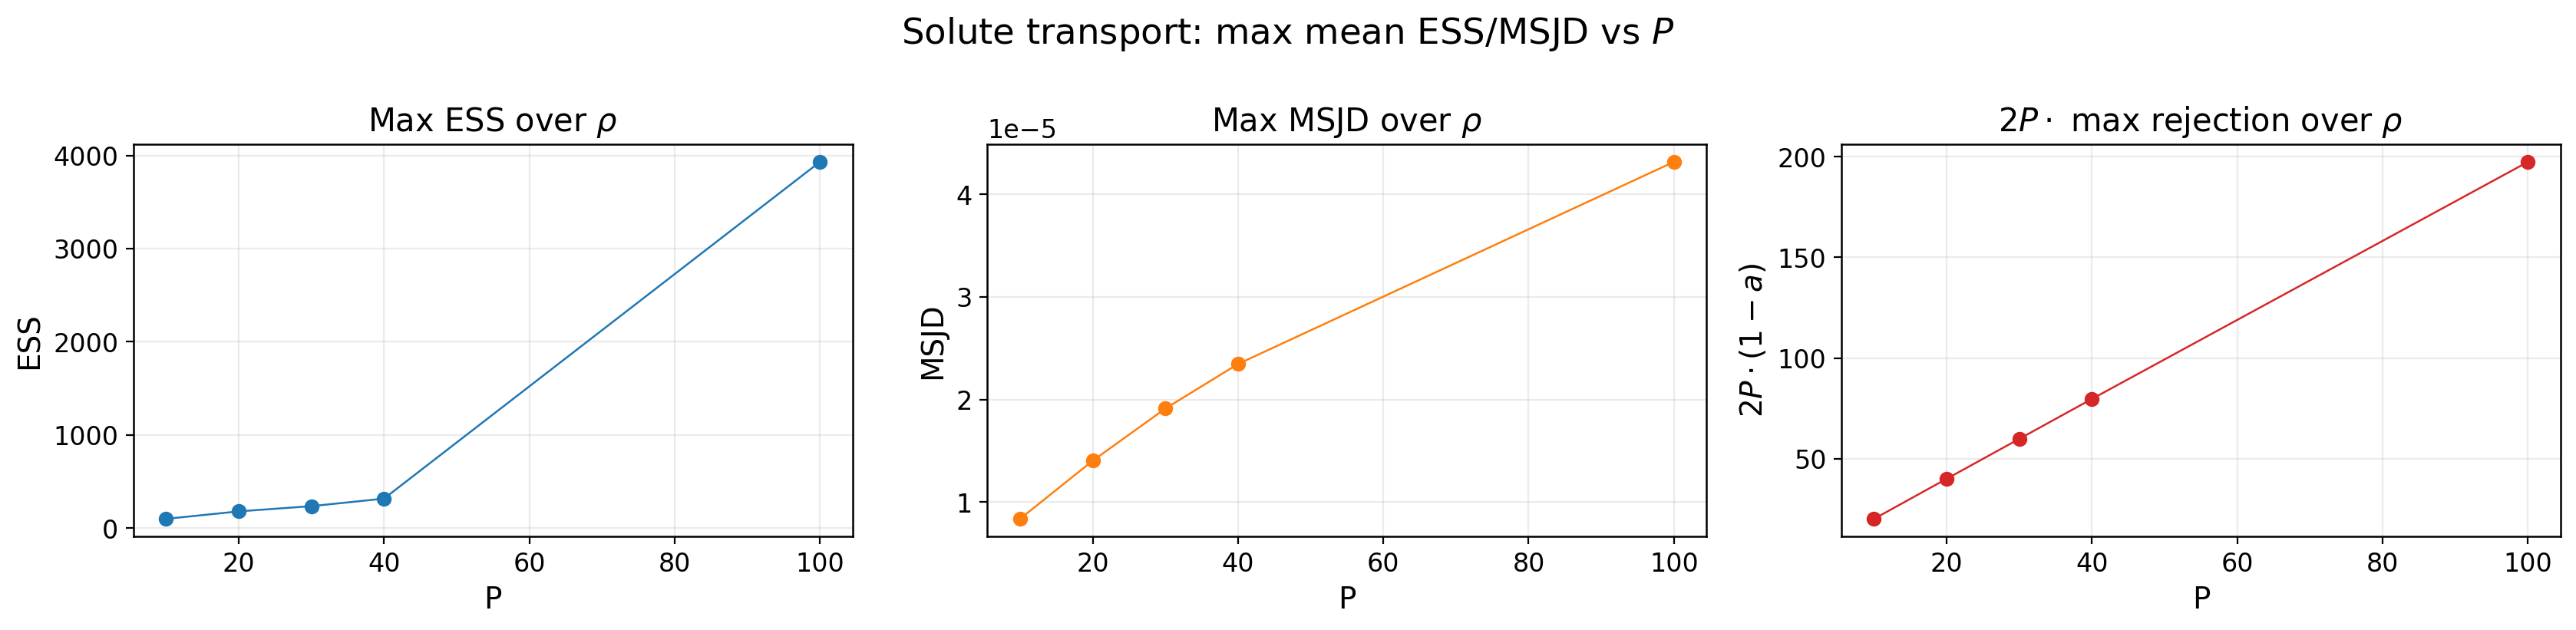

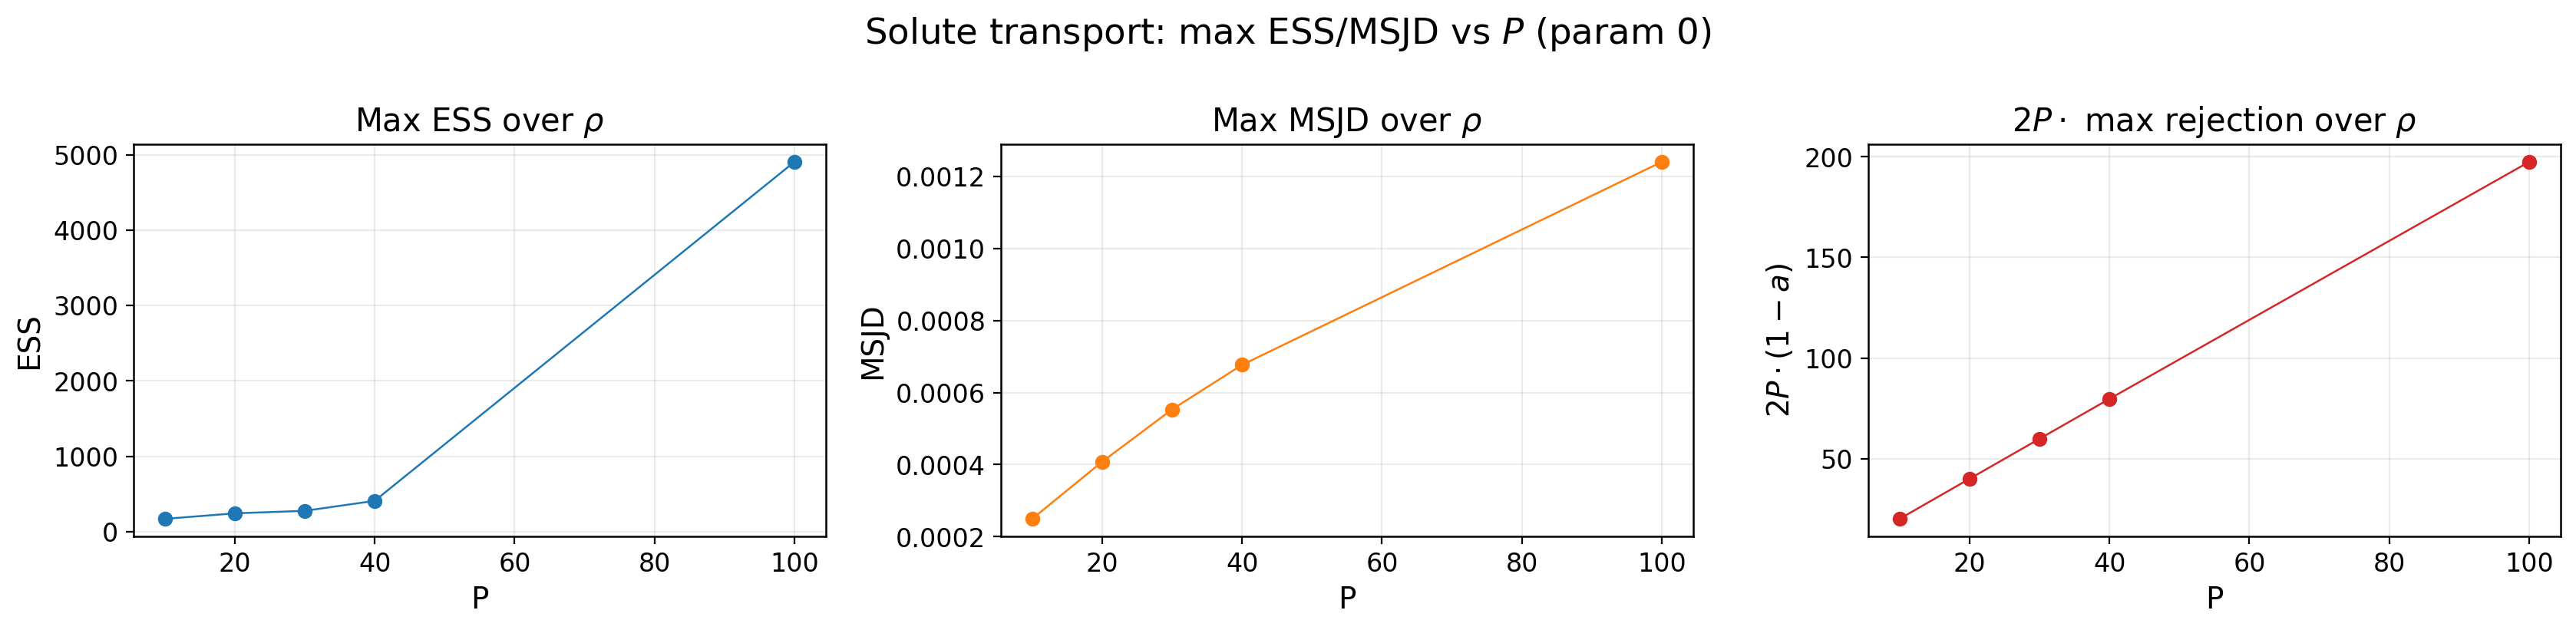

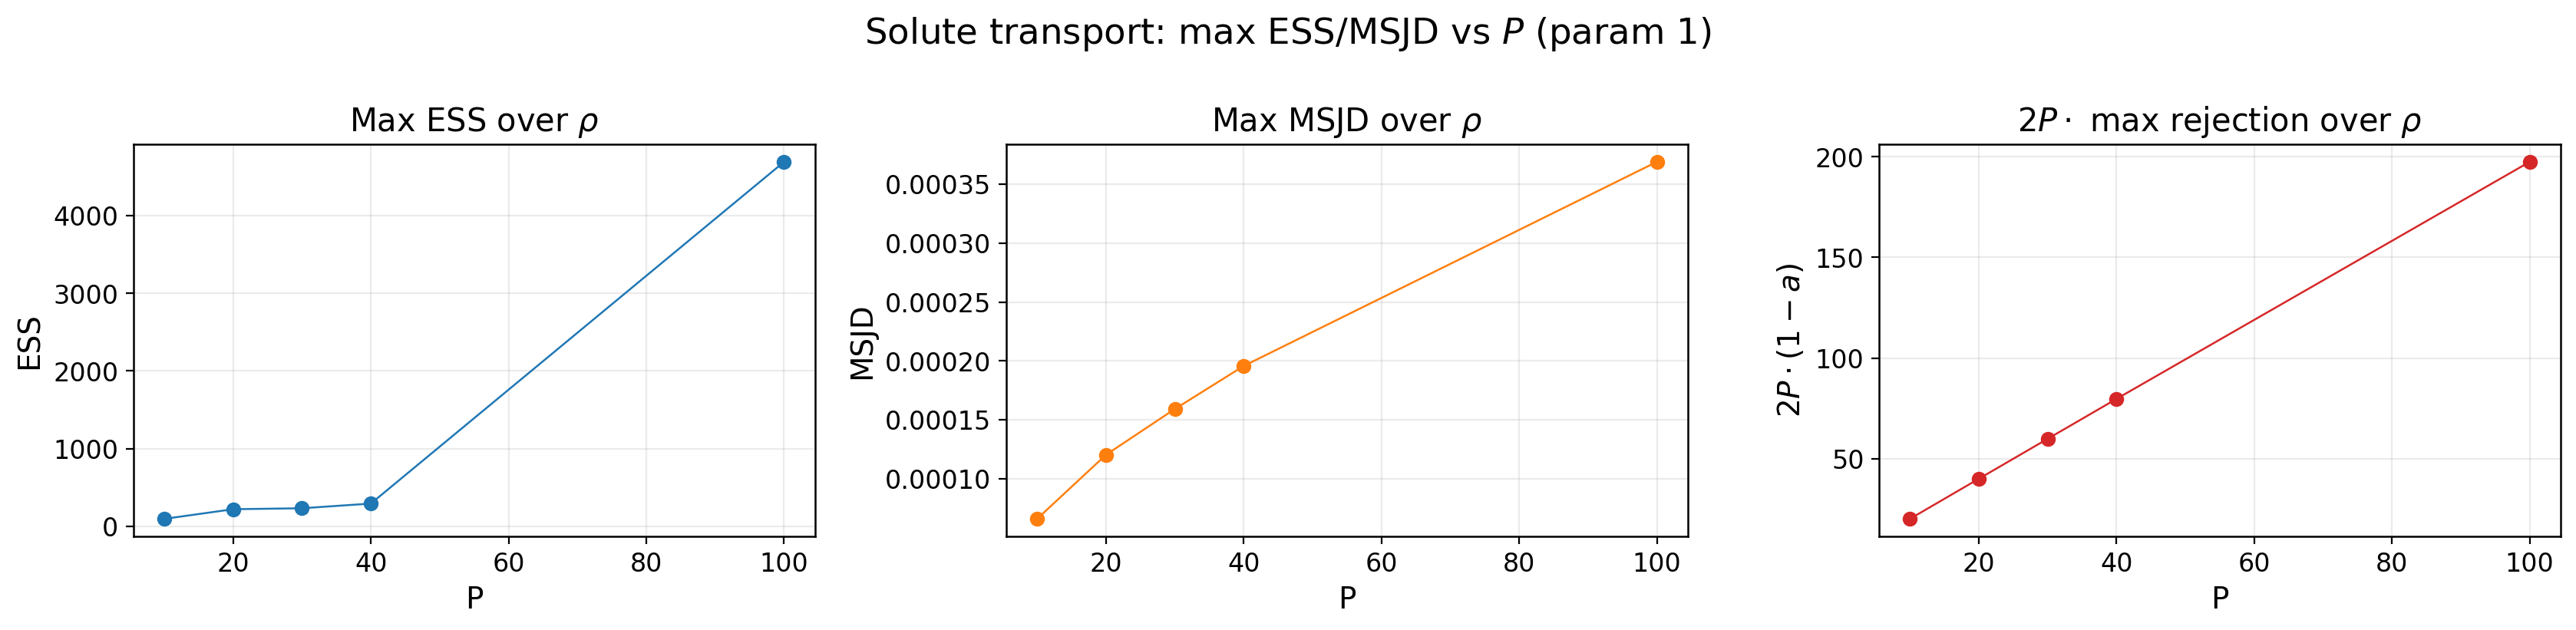

In [67]:
# Max ess/msjd vs P at best rho (one line per metric)
apply_pub_style()

P_sorted = sorted(P_list)

def _max_metric_over_rho(P, metric_key, param_index=None):
    values = []
    for rho in rho_list:
        entry = results.get('mpcn', {}).get(P, {}).get(float(rho))
        if entry is None:
            continue
        metrics = entry.get('metrics', {})
        if param_index is None:
            value = metrics.get(metric_key)
        else:
            per_param = metrics.get(metric_key)
            if per_param is None:
                value = None
            else:
                try:
                    value = per_param[param_index]
                except (IndexError, TypeError):
                    value = None
        if value is None or np.isnan(value):
            continue
        values.append(value)
    return float(np.nanmax(values)) if values else np.nan

def _worst_rejection_over_rho(P, max_rho=0.95):
    reject_vals = []
    for rho in rho_list:
        if rho > max_rho:
            continue
        entry = results.get('mpcn', {}).get(P, {}).get(float(rho))
        if entry is None:
            continue
        accept_rate = entry.get('accept_rate')
        if accept_rate is None or np.isnan(accept_rate):
            continue
        reject_vals.append(1.0 - float(accept_rate))
        max_rejection = float(np.nanmax(reject_vals)) if reject_vals else np.nan
        # print(f"P={P}, max rejection over rho <= {max_rho}: {max_rejection:.4f}")
    return max_rejection

def _plot_max_vs_P(title, ess_vals, msjd_vals, scaled_reject_vals, filename):
    fig, axes = plt.subplots(1, 3, figsize=(17.0, 4.2), sharex=True)
    ax_ess, ax_msjd, ax_reject = axes

    ax_ess.plot(P_sorted, ess_vals, marker='o', color='tab:blue')
    ax_msjd.plot(P_sorted, msjd_vals, marker='o', color='tab:orange')
    ax_reject.plot(P_sorted, scaled_reject_vals, marker='o', color='tab:red')

    ax_ess.set_title(r'Max ESS over $\rho$')
    ax_msjd.set_title(r'Max MSJD over $\rho$')
    ax_reject.set_title(r'$2P \cdot$ max rejection over $\rho$')
    ax_ess.set_xlabel('P')
    ax_msjd.set_xlabel('P')
    ax_reject.set_xlabel('P')
    ax_ess.set_ylabel('ESS')
    ax_msjd.set_ylabel('MSJD')
    ax_reject.set_ylabel(r'$2P \cdot (1 - a)$')
    ax_ess.grid(alpha=0.25)
    ax_msjd.grid(alpha=0.25)
    ax_reject.grid(alpha=0.25)

    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(reports_dir / filename, bbox_inches='tight')
    plt.show()

mean_ess = [_max_metric_over_rho(P, 'ess_mean') for P in P_sorted]
mean_msjd = [_max_metric_over_rho(P, 'msjd_mean') for P in P_sorted]
mean_reject = [_worst_rejection_over_rho(P) for P in P_sorted]
mean_scaled_reject = [2.0 * P * r if not np.isnan(r) else np.nan for P, r in zip(P_sorted, mean_reject)]
_plot_max_vs_P(
    r'Solute transport: max mean ESS/MSJD vs $P$',
    mean_ess,
    mean_msjd,
    mean_scaled_reject,
    f'solute_transport_max_mean_ess_msjd_vs_P_seed{seed_base}.png',
)

p0_ess = [_max_metric_over_rho(P, 'ess_per_param', param_index=0) for P in P_sorted]
p0_msjd = [_max_metric_over_rho(P, 'msjd_per_param', param_index=0) for P in P_sorted]
p0_reject = [_worst_rejection_over_rho(P) for P in P_sorted]
p0_scaled_reject = [2.0 * P * r if not np.isnan(r) else np.nan for P, r in zip(P_sorted, p0_reject)]
_plot_max_vs_P(
    r'Solute transport: max ESS/MSJD vs $P$ (param 0)',
    p0_ess,
    p0_msjd,
    p0_scaled_reject,
    f'solute_transport_max_param0_ess_msjd_vs_P_seed{seed_base}.png',
)

p1_ess = [_max_metric_over_rho(P, 'ess_per_param', param_index=1) for P in P_sorted]
p1_msjd = [_max_metric_over_rho(P, 'msjd_per_param', param_index=1) for P in P_sorted]
p1_reject = [_worst_rejection_over_rho(P) for P in P_sorted]
p1_scaled_reject = [2.0 * P * r if not np.isnan(r) else np.nan for P, r in zip(P_sorted, p1_reject)]
_plot_max_vs_P(
    r'Solute transport: max ESS/MSJD vs $P$ (param 1)',
    p1_ess,
    p1_msjd,
    p1_scaled_reject,
    f'solute_transport_max_param1_ess_msjd_vs_P_seed{seed_base}.png',
)

## Analyzing mixing for extreme rho

In [ ]:
# Load extra rho chains for the edge ranges (no sampling)
rho_low = np.round(np.arange(0.0, 0.1001, 0.005), 5)
rho_high = np.round(np.arange(0.85, 1.0001, 0.005), 5)
rho_edges = np.unique(np.concatenate([rho_low, rho_high]))

def ensure_mpcn_rho_results(rho_values):
    for P in P_list:
        results['mpcn'].setdefault(P, {})
        for rho in rho_values:
            rho_key = float(rho)
            if rho_key in results['mpcn'][P]:
                continue
            samples_path, metrics_path = chain_cache_paths(
                'mpcn', rho=rho_key, seed_base=seed_base, P=P
            )
            diag_path = mpcn_diag_path(P, rho_key, seed_base)
            loaded = load_chain_bundle(samples_path, metrics_path)
            if loaded is None:
                print(f'mPCN edge rho missing: P={P}, rho={rho_key:.3f} (skipping)')
                continue
            chain, accept_rate, runtime_sec, metrics = loaded
            if metrics is None or 'ess_per_param' not in metrics:
                metrics = summarize_chain_metrics(
                    chain, runtime_sec, burn_in=burn_in, max_lag=max_lag
                )
                save_metrics_json(metrics_path, metrics, accept_rate, runtime_sec)
            snapshot, mean_dist_samples, mean_sq_dist_samples = load_mpcn_diagnostics(diag_path)
            results['mpcn'][P][rho_key] = {
                'chain': chain,
                'runtime_sec': runtime_sec,
                'accept_rate': accept_rate,
                'metrics': metrics,
                'snapshot': snapshot,
                'mean_dist_samples': np.asarray(mean_dist_samples, dtype=float),
                'mean_sq_dist_samples': np.asarray(mean_sq_dist_samples, dtype=float),
            }
            accept_display = np.nan if accept_rate is None else accept_rate
            print(
                f'mPCN edge rho loaded: P={P}, rho={rho_key:.3f}, '
                f'accept={accept_display:.3f}, runtime={runtime_sec:.2f}s'
            )

ensure_mpcn_rho_results(rho_edges)

In [ ]:
# Zoomed-in rho ranges (0-0.1 and 0.9-1.0)
apply_pub_style()

rho_low = np.round(np.arange(0.0, 0.1001, 0.005), 5)
rho_high = np.round(np.arange(0.85, 1.0001, 0.005), 5)

P_sorted = sorted(P_list)
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(P_sorted)))
color_by_P = {P: colors[i] for i, P in enumerate(P_sorted)}

def get_metric_for_rho(results_dict, P, rho, metric_key):
    entry = results_dict.get(P, {}).get(float(rho))
    if entry is None:
        return np.nan
    return entry['metrics'][metric_key]

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.2), sharey=True)
ax_low, ax_high = axes

for P in P_sorted:
    ess_low = [get_metric_for_rho(results['mpcn'], P, rho, 'ess_mean') for rho in rho_low]
    ess_high = [get_metric_for_rho(results['mpcn'], P, rho, 'ess_mean') for rho in rho_high]
    ax_low.plot(rho_low, ess_low, marker='o', color=color_by_P[P], label=f'P={P}')
    ax_high.plot(rho_high, ess_high, marker='o', color=color_by_P[P], label=f'P={P}')

ax_low.set_title(r'ESS vs $\rho$ (0.0-0.1)')
ax_low.set_xlabel(r'$\rho$')
ax_low.set_ylabel('Effective Sample Size')
ax_low.grid(alpha=0.25)

ax_high.set_title(r'ESS vs $\rho$ (0.9-1.0)')
ax_high.set_xlabel(r'$\rho$')
ax_high.grid(alpha=0.25)

handles, labels = ax_low.get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
fig.suptitle(r'Solute transport: ESS at $\rho$ range edges')
fig.tight_layout()

filename = f'solute_transport_ess_rho_edges_0.00-0.10_0.85-1.00_seed{seed_base}.png'
fig.savefig(reports_dir / filename, bbox_inches='tight')
plt.show()

## Pairplots

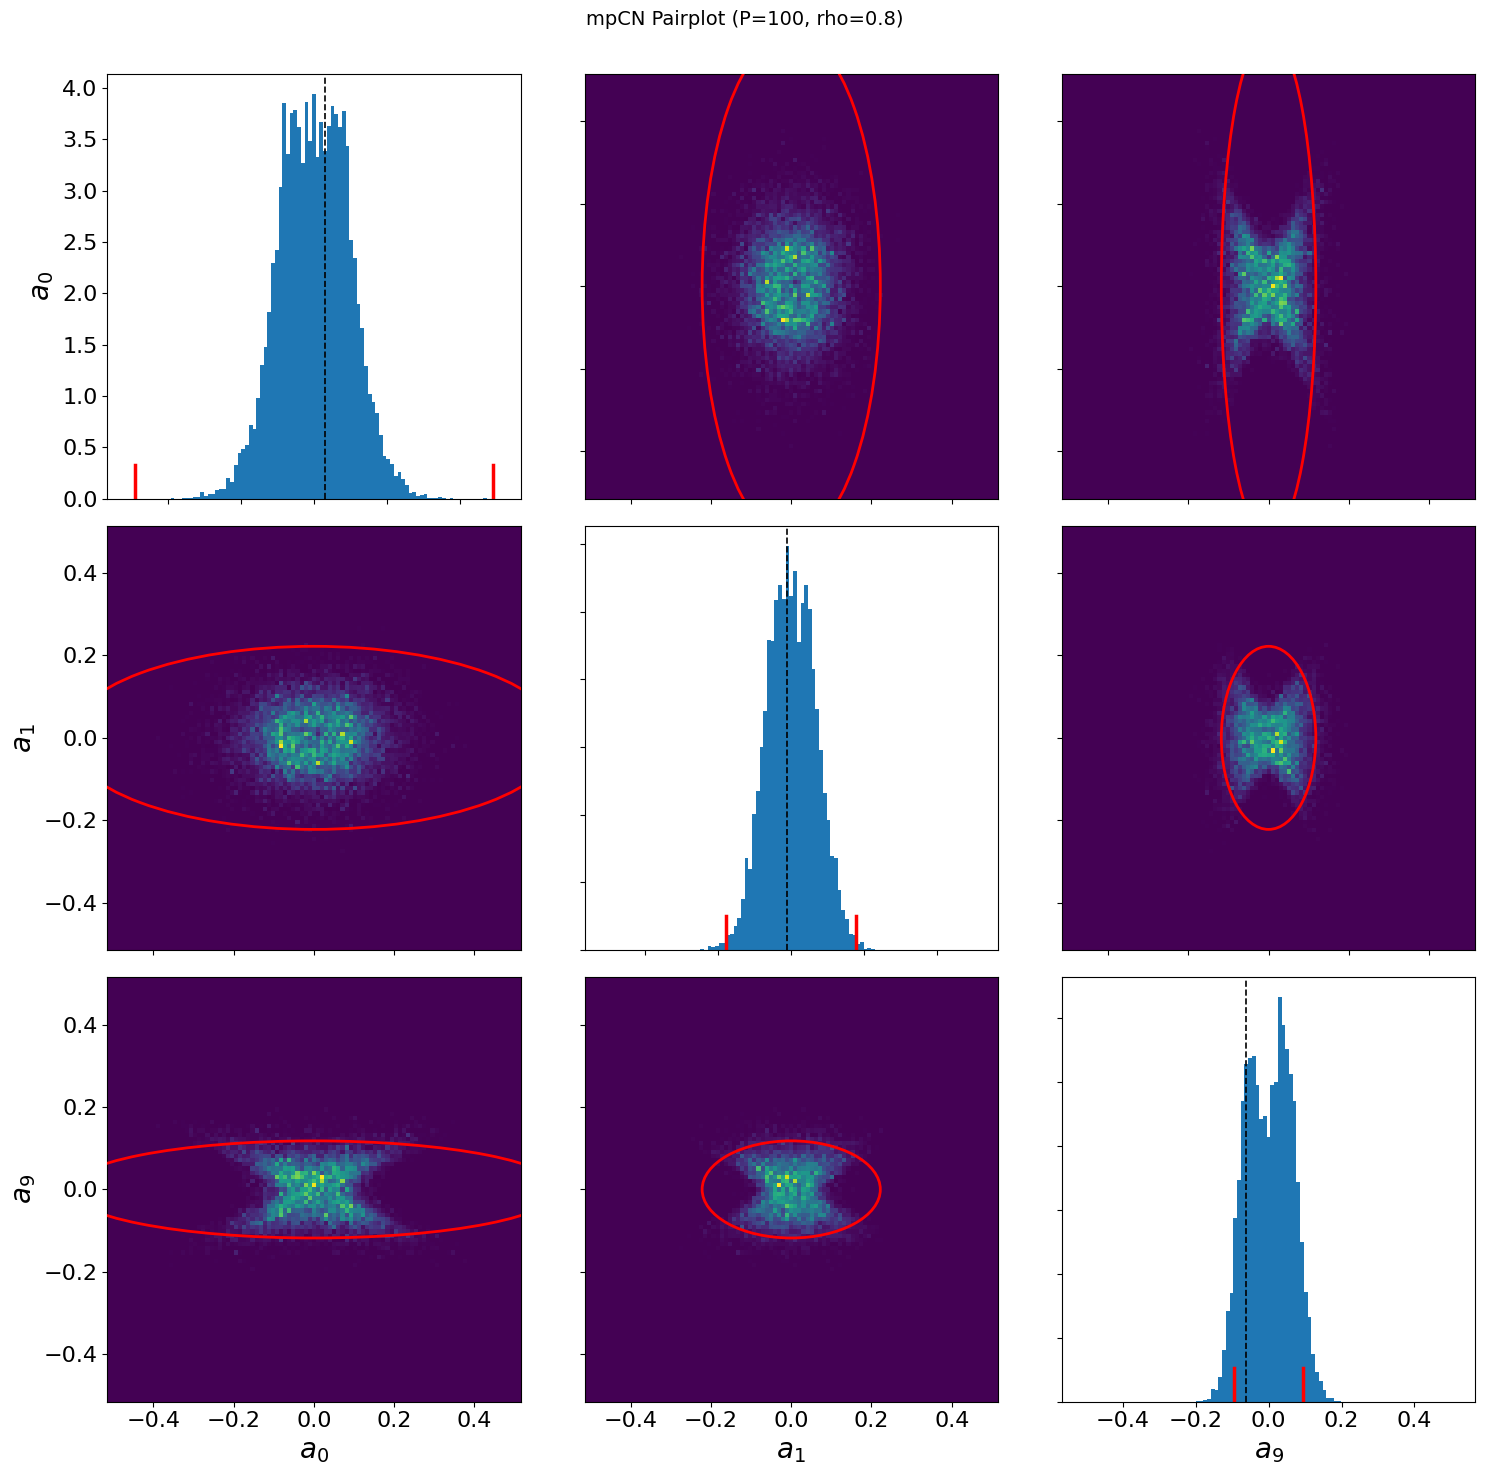

In [18]:
# Pairplots for a selected P and rho
import importlib
importlib.reload(multiproposal.plotting.diagnostics)
from multiproposal.plotting.diagnostics import make_hist_grid_comps

P_pair = 100
rho_pair = 0.8

tick_font_size = 16
axis_label_size = 20

comp_list = [0, 1, 9]
comp_list = [idx for idx in comp_list if idx < problem.dim]
if len(comp_list) < 2:
    raise ValueError('Need at least two parameters for pairplots.')

post_chain_mpcn = results['mpcn'][P_pair][rho_pair]['chain'][burn_in:]
# post_chain_mess_uniform = results['mess_uniform'][P_pair]['chain'][burn_in:]
# post_chain_mess_euclid = results['mess_euclid_sq'][P_pair]['chain'][burn_in:]

# combined = np.vstack([post_chain_mpcn, post_chain_mess_uniform, post_chain_mess_euclid])
combined = np.vstack([post_chain_mpcn])
R = 1 * np.max(np.abs(combined))
dr = 0.01

prior_cov = np.diag(data['prior_diag'])
label_map = {
    comp_list[0]: rf"$a_{{{comp_list[0]}}}$",
    comp_list[1]: rf"$a_{{{comp_list[1]}}}$",
}
true_values = data.get('a_true', None)

_ = make_hist_grid_comps(
    R=R,
    dr=dr,
    samples=post_chain_mpcn,
    comp_list=comp_list,
    save_path=reports_dir / f'solute_transport_mpcn_pairplot_P{P_pair}_rho{rho_pair:.2f}_seed{seed_base}.png',
    C=prior_cov,
    beta=0.95,
    hide_plot=False,
    label_map=label_map,
    font_size=12,
    tick_label_size=tick_font_size,
    axis_label_size=axis_label_size,
    title=f'mpCN Pairplot (P={P_pair}, rho={rho_pair:.1f})',
    true_values=true_values
 )

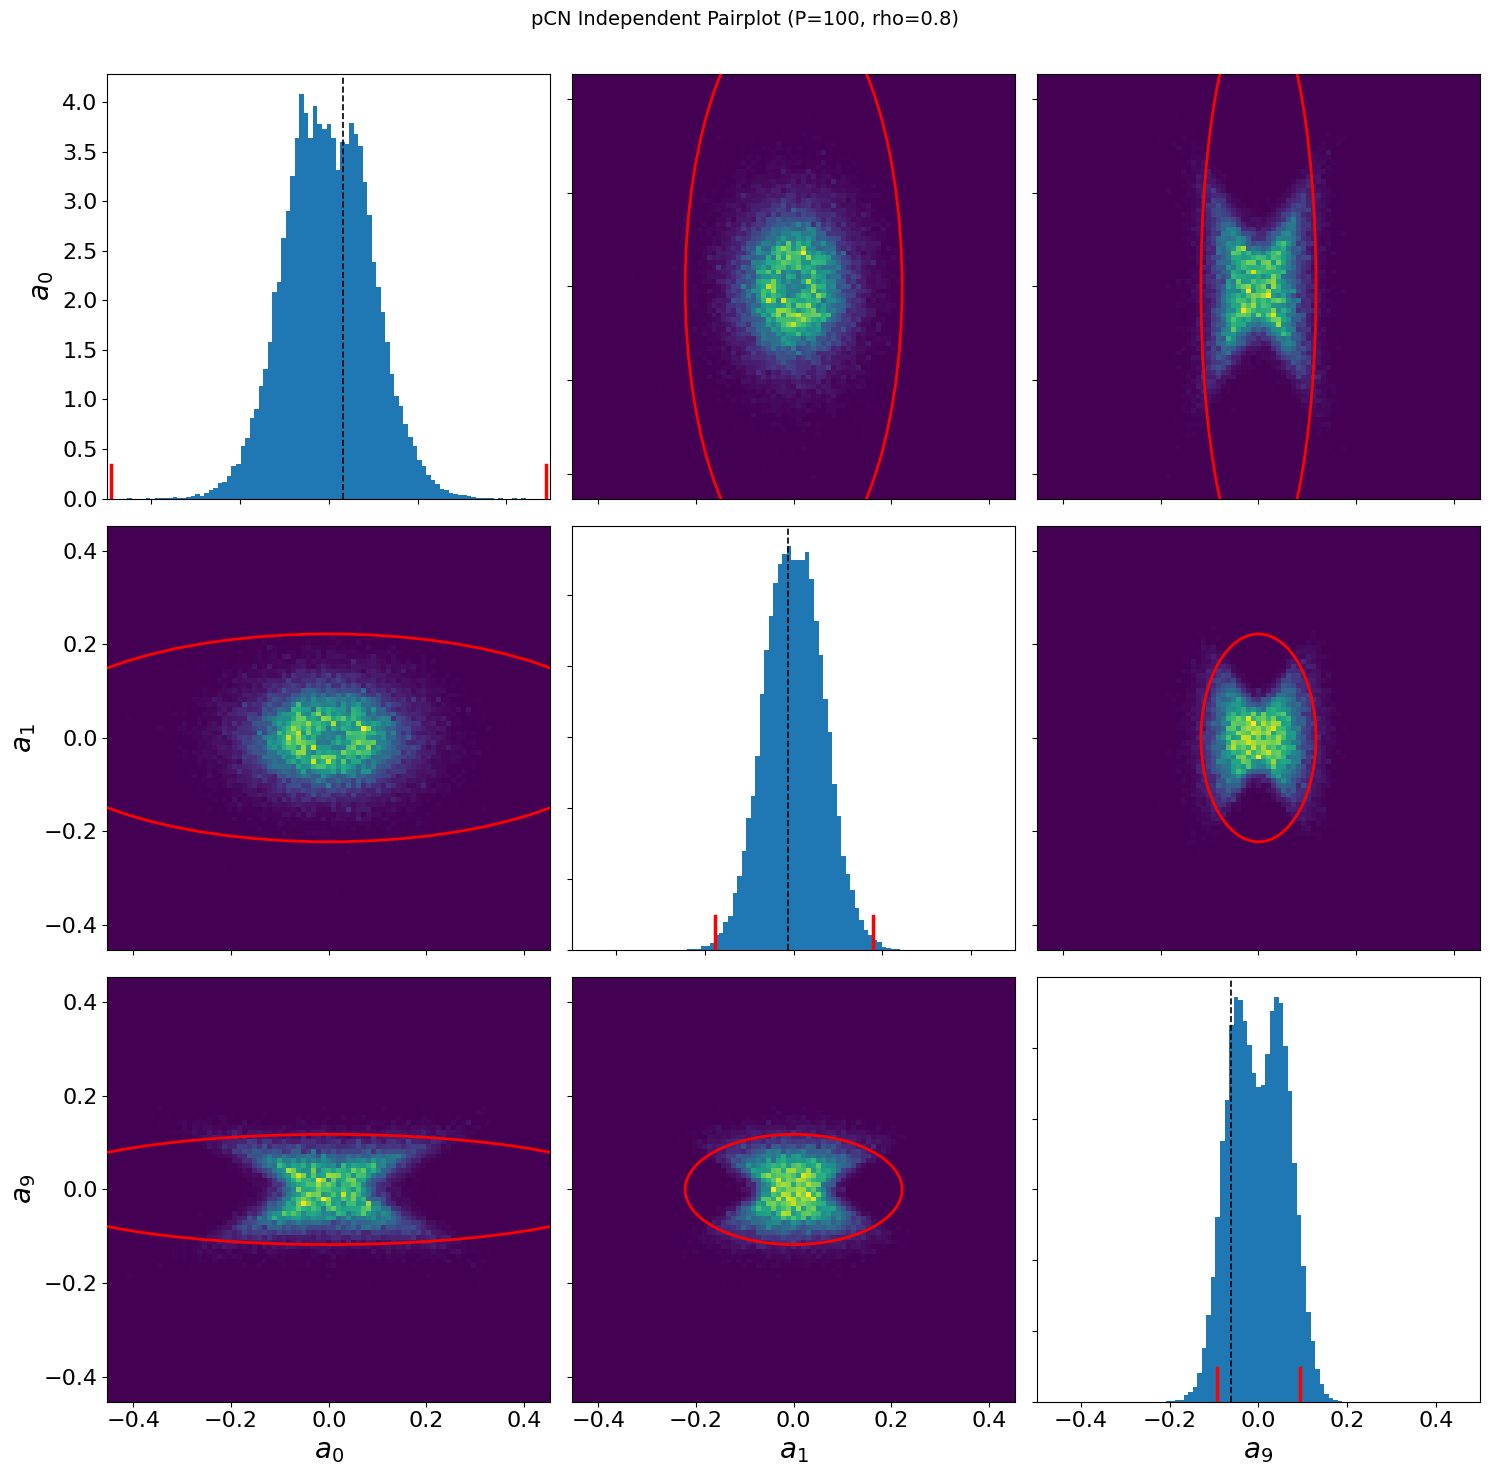

In [19]:
# Pairplot: pooled independent pCN chains (P_pair chains)
from multiproposal.plotting.diagnostics import make_hist_grid_comps

P_pair = 100
rho_pair = 0.8

tick_font_size = 16
axis_label_size = 20

comp_list = [0, 1, 9]
comp_list = [idx for idx in comp_list if idx < problem.dim]
if len(comp_list) < 2:
    raise ValueError('Need at least two parameters for pairplots.')

pairplot_burnin = burn_in
pairplot_thin = 100

index_payload = load_independent_index(rho_pair, seed_base)
if index_payload is None:
    raise ValueError(f'No independent pCN index for rho={rho_pair:.3f}.')
chain_files = [path for path in independent_chain_files(index_payload) if path.exists()]
if len(chain_files) < P_pair:
    raise ValueError(f'Need {P_pair} chains, only found {len(chain_files)}.')

segments = []
for path in chain_files[:P_pair]:
    with np.load(path, allow_pickle=False) as npz:
        chain = npz['chain']
    if chain.shape[0] <= pairplot_burnin:
        continue
    segment = chain[pairplot_burnin::pairplot_thin]
    if segment.size == 0:
        continue
    segments.append(segment)

if not segments:
    raise ValueError('No usable samples from independent pCN chains.')

post_chain_pcn_indep = np.vstack(segments)

combined = np.vstack([post_chain_pcn_indep])
R = 1 * np.max(np.abs(combined))
dr = 0.01

prior_cov = np.diag(data['prior_diag'])
label_map = {
    comp_list[0]: rf"$a_{{{comp_list[0]}}}$",
    comp_list[1]: rf"$a_{{{comp_list[1]}}}$",
}
true_values = data.get('a_true', None)

_ = make_hist_grid_comps(
    R=R,
    dr=dr,
    samples=post_chain_pcn_indep,
    comp_list=comp_list,
    save_path=reports_dir / f'solute_transport_pcn_indep_pairplot_P{P_pair}_rho{rho_pair:.2f}_seed{seed_base}.png',
    C=prior_cov,
    beta=0.95,
    hide_plot=False,
    label_map=label_map,
    font_size=12,
    tick_label_size=tick_font_size,
    axis_label_size=axis_label_size,
    title=f'pCN Independent Pairplot (P={P_pair}, rho={rho_pair:.1f})',
    true_values=true_values
 )